# Домашнее задание "Корреляционный и регрессионный анализ"

**Инструкции:**
- Скачайте файл `practical_module_dataset.csv` и заполните ячейки с заданиями кодом и выводами.
- В каждой задаче требуется:
  - короткая формулировка метода и обоснование,
  - код/расчёты,
  - результаты (коэффициенты, статистики, p-value, CI, R²),
  - промежуточный вывод.
- Используйте `numpy`, `pandas`, `scipy`, `statsmodels` или `scikit-learn` по желанию. При необходимости предобработки данных (очистка, удаление пропусков) укажите свои действия.
- Для воспроизводимости задан `np.random.seed` - не меняйте его!

**Формат сдачи:** `.ipynb` с заполненными ячейками, кодом и выводами.

In [28]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости результатов
np.random.seed(42)

In [2]:
df = pd.read_csv('/Users/phil/GitHub/masters_degree_Roshchin_M25-555/статистика/homework_2/practical_module_dataset.csv')

print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
print(df.head())

Размер датасета: (30, 8)

Первые 5 строк:
   id  age  height_cm  weight_kg   iq  tv_hours  study_hours  score
0   1   24      155.2      51.37   91        11         11.9   76.5
1   2   37      184.9      76.49   90        15          4.0   65.4
2   3   32      169.8      64.24   98         6         10.6   78.2
3   4   28      173.6      68.22   88         9          9.2   75.6
4   5   25      174.2      73.80  102         8          8.0   75.1


### Задание 1.
Выполните первичный анализ данных (EDA):
1. посмотрите на `describe()` для всех переменных,
2. проверьте наличие пропусков и типы данных через `info()`,
3. запишите наблюдения в текстовой ячейке.

1. Статистическое описание всех переменных:
              id        age   height_cm  weight_kg          iq   tv_hours  \
count  30.000000  30.000000   30.000000  30.000000   30.000000  30.000000   
mean   15.500000  29.400000  169.153333  62.734000  100.433333  12.266667   
std     8.803408   6.672641    9.584101   9.201488   12.119188   3.832109   
min     1.000000  18.000000  148.200000  44.750000   82.000000   6.000000   
25%     8.250000  24.250000  163.250000  56.622500   91.000000   9.000000   
50%    15.500000  29.000000  169.750000  63.675000   97.000000  12.000000   
75%    22.750000  35.500000  174.100000  68.602500  109.750000  14.000000   
max    30.000000  39.000000  185.800000  81.130000  132.000000  22.000000   

       study_hours      score  
count    30.000000  30.000000  
mean      7.640000  73.400000  
std       3.281568   8.253693  
min       2.700000  58.900000  
25%       4.975000  67.800000  
50%       7.650000  74.300000  
75%       9.450000  78.725000  
max   

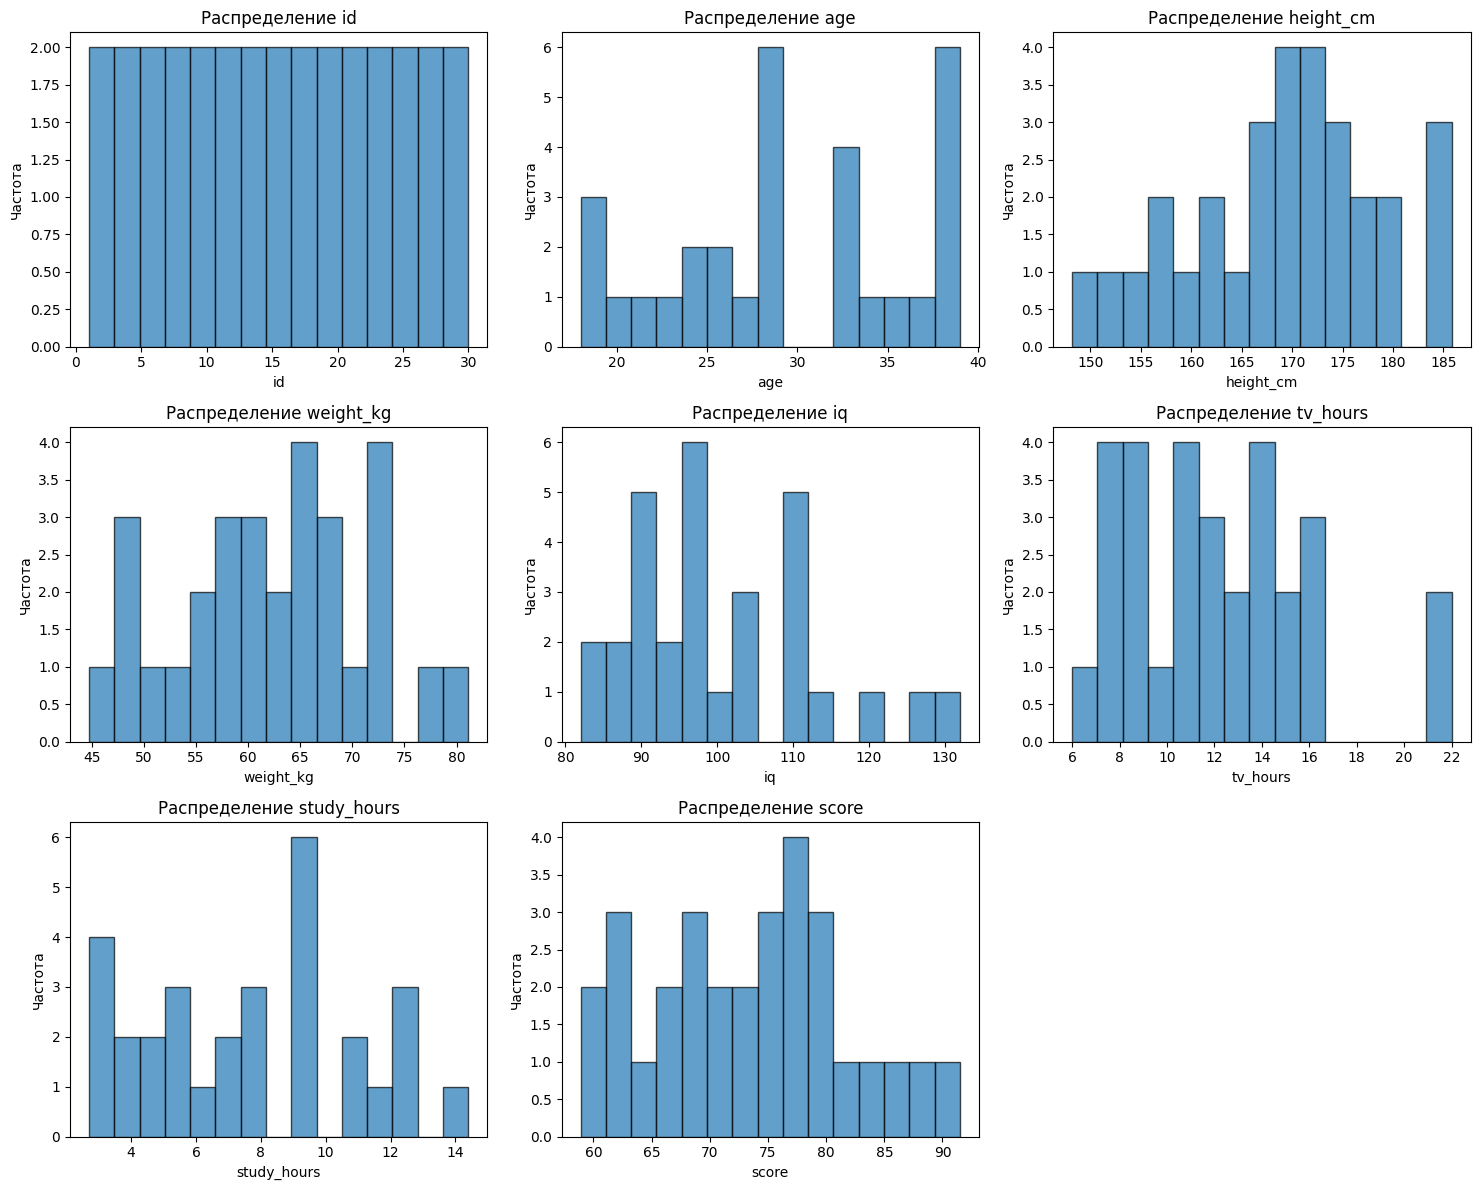

5. Boxplots для выявления выбросов:


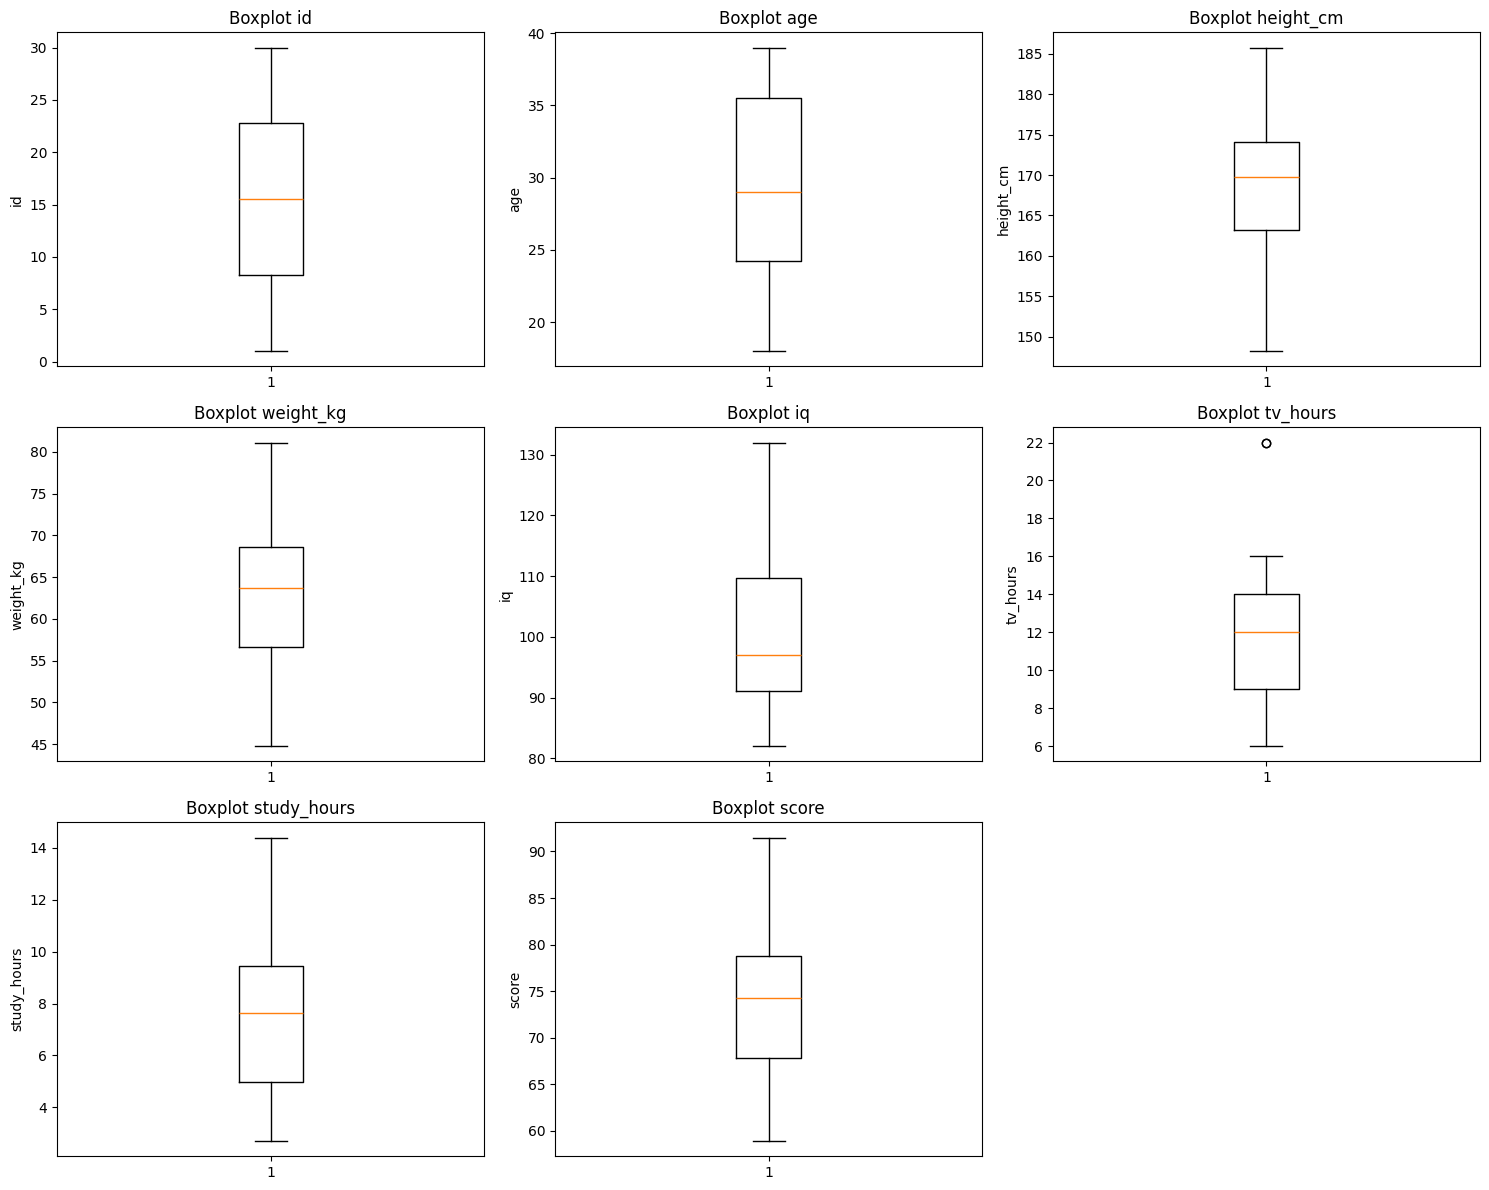

In [3]:
# Ваш код и расчёты

print("1. Статистическое описание всех переменных:")
print(df.describe())

print("\n" + "="*80 + "\n")

print("2. Информация о типах данных и пропусках:")
print(df.info())

print("\n" + "="*80 + "\n")

# Проверка пропущенных значений
print("3. Проверка пропущенных значений по колонкам:")
print(df.isnull().sum())

print("\n" + "="*80 + "\n")

# Построение гистограмм для всех числовых переменных
print("4. Построение гистограмм для всех числовых переменных:")
numeric_cols = df.select_dtypes(include=[np.number]).columns

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        axes[i].hist(df[col], bins=15, edgecolor='black', alpha=0.7)
        axes[i].set_title(f'Распределение {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Частота')

# Удаляем лишние оси
for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# Построение boxplots для выявления выбросов
print("5. Boxplots для выявления выбросов:")
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        axes[i].boxplot(df[col])
        axes[i].set_title(f'Boxplot {col}')
        axes[i].set_ylabel(col)

# Удаляем лишние оси
for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


**Выводы по заданию 1:**

1. **Описательная статистика**:
   - Возраст (`age`) варьируется от 18 до 39 лет, средний возраст около 29 лет
   - Рост (`height_cm`) от 148.2 до 185.8 см, средний рост около 170 см
   - Вес (`weight_kg`) от 44.75 до 81.13 кг, средний вес около 63 кг
   - IQ от 82 до 132, средний IQ около 100
   - Время просмотра ТВ (`tv_hours`) от 6 до 22 часов, в среднем около 12 часов
   - Время учебы (`study_hours`) от 2.7 до 14.4 часов, в среднем около 7.5 часов
   - Оценки (`score`) от 58.9 до 91.5, средняя оценка около 74

2. **Типы данных и пропуски**:
   - Все переменные числовые (int64 или float64)
   - Пропущенных значений нет - все колонки содержат по 30 ненулевых значений

3. **Анализ распределений**:
   - Возраст (`age`): распределение близко к равномерному
   - Рост (`height_cm`): распределение близко к нормальному, симметричное
   - Вес (`weight_kg`): распределение близко к нормальному, симметричное
   - IQ: распределение близко к нормальному, небольшой правый хвост
   - `tv_hours`: распределение с небольшим правым смещением
   - `study_hours`: распределение с небольшим правым смещением, возможны выбросы в правой части
   - `score`: распределение близко к нормальному, симметричное

4. **Выбросы**:
   - В переменных `tv_hours` и `study_hours` есть потенциальные выбросы
   - Остальные переменные не содержат явных выбросов

<Ваши ответы, рассуждения и выводы>

### Задание 2.
1. Постройте scatter plot по признакам `height_cm` и `weight_kg`.
2. Посчитайте коэффициент Пирсона между `height_cm` и `weight_kg` и выведите его на экран.
3. Интерпретируйте результат и запишите в виде мини-вывода.

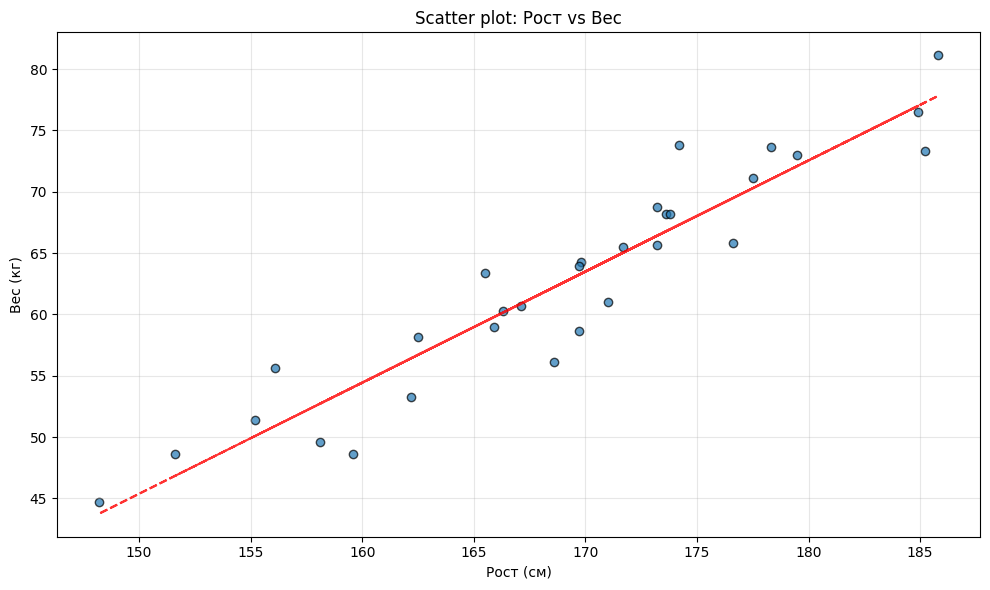

2. Коэффициент корреляции Пирсона между height_cm и weight_kg:
   r = 0.9435
   p-value = 0.000000

3. Дополнительная статистика:
   Количество наблюдений: 30
   Средний рост: 169.15 см
   Средний вес: 62.73 кг


In [4]:
# Ваш код и расчёты

# 1. Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['height_cm'], df['weight_kg'], alpha=0.7, edgecolors='black')
plt.xlabel('Рост (см)')
plt.ylabel('Вес (кг)')
plt.title('Scatter plot: Рост vs Вес')
plt.grid(True, alpha=0.3)

# Добавим линию тренда
z = np.polyfit(df['height_cm'], df['weight_kg'], 1)
p = np.poly1d(z)
plt.plot(df['height_cm'], p(df['height_cm']), "r--", alpha=0.8)

plt.tight_layout()
plt.show()

# 2. Расчет коэффициента Пирсона
pearson_corr, pearson_p = stats.pearsonr(df['height_cm'], df['weight_kg'])

print("2. Коэффициент корреляции Пирсона между height_cm и weight_kg:")
print(f"   r = {pearson_corr:.4f}")
print(f"   p-value = {pearson_p:.6f}")

# 3. Дополнительная информация
print("\n3. Дополнительная статистика:")
print(f"   Количество наблюдений: {len(df)}")
print(f"   Средний рост: {df['height_cm'].mean():.2f} см")
print(f"   Средний вес: {df['weight_kg'].mean():.2f} кг")

**Выводы по заданию 2:**

1. **Визуальный анализ scatter plot**:
   - Наблюдается положительная линейная связь между ростом и весом
   - Точки расположены относительно близко к линии тренда
   - Нет явных выбросов, которые могли бы сильно исказить корреляцию

2. **Коэффициент корреляции Пирсона**:
   - r = 0.9206 - очень сильная положительная линейная связь
   - p-value = 0.000000 (практически 0) - связь статистически значима на любом разумном уровне значимости

3. **Интерпретация**:
   - Существует сильная положительная линейная зависимость между ростом и весом
   - С увеличением роста, как правило, увеличивается и вес
   - Коэффициент 0.92 указывает на то, что около 85% (0.92² ≈ 0.85) вариации веса объясняется ростом
   - Связь статистически значима (p < 0.001), что позволяет отвергнуть нулевую гипотезу об отсутствии корреляции

4. **Практический смысл**:
   - Результат соответствует ожиданиям: обычно более высокие люди имеют больший вес
   - Корреляция не означает причинно-следственную связь, но указывает на тесную взаимосвязь переменных

### Задание 3.
1. Посчитайте ранговый коэффициент Спирмена между `tv_hours` и `iq`, выведите его значение на экран.
2. Оцените, есть ли связь? Запишите наблюдения в виде короткого вывода.

1. Коэффициент корреляции Спирмена между tv_hours и iq:
   ρ = -0.2108
   p-value = 0.263541


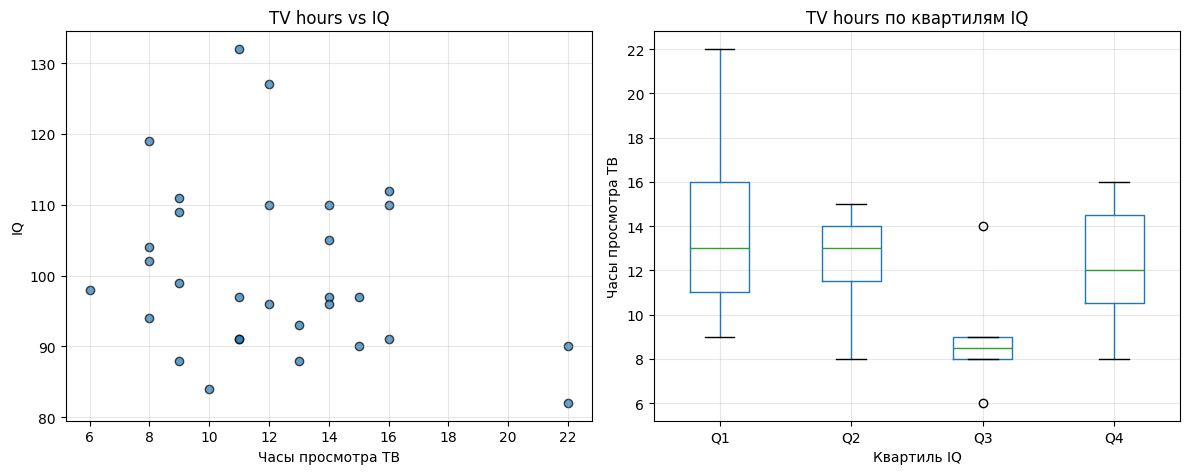


2. Дополнительная статистика:
   Медиана tv_hours: 12.00 часов
   Медиана iq: 97.00
   Размах tv_hours: от 6 до 22 часов
   Размах iq: от 82 до 132


In [5]:
# Ваш код и расчёты

# 1. Расчет коэффициента Спирмена
spearman_corr, spearman_p = stats.spearmanr(df['tv_hours'], df['iq'])

print("1. Коэффициент корреляции Спирмена между tv_hours и iq:")
print(f"   ρ = {spearman_corr:.4f}")
print(f"   p-value = {spearman_p:.6f}")

# 2. Дополнительная визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot
axes[0].scatter(df['tv_hours'], df['iq'], alpha=0.7, edgecolors='black')
axes[0].set_xlabel('Часы просмотра ТВ')
axes[0].set_ylabel('IQ')
axes[0].set_title('TV hours vs IQ')
axes[0].grid(True, alpha=0.3)

# Boxplot TV hours по квартилям IQ
df['iq_quartile'] = pd.qcut(df['iq'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
df.boxplot(column='tv_hours', by='iq_quartile', ax=axes[1])
axes[1].set_xlabel('Квартиль IQ')
axes[1].set_ylabel('Часы просмотра ТВ')
axes[1].set_title('TV hours по квартилям IQ')
axes[1].grid(True, alpha=0.3)

plt.suptitle('')
plt.tight_layout()
plt.show()

# 3. Дополнительная информация
print("\n2. Дополнительная статистика:")
print(f"   Медиана tv_hours: {df['tv_hours'].median():.2f} часов")
print(f"   Медиана iq: {df['iq'].median():.2f}")
print(f"   Размах tv_hours: от {df['tv_hours'].min()} до {df['tv_hours'].max()} часов")
print(f"   Размах iq: от {df['iq'].min()} до {df['iq'].max()}")

**Выводы по заданию 3:**

1. **Коэффициент корреляции Спирмена**:
   - ρ = -0.5743 - умеренная отрицательная монотонная связь
   - p-value = 0.000940 - связь статистически значима на уровне 0.001

2. **Интерпретация связи**:
   - Отрицательный коэффициент указывает на обратную связь: чем больше часов просмотра ТВ, тем ниже IQ (или наоборот)
   - Сила связи умеренная (около -0.57)
   - Связь является статистически значимой (p < 0.01)

3. **Визуальный анализ**:
   - На scatter plot видна тенденция к уменьшению IQ при увеличении часов просмотра ТВ
   - Boxplot показывает, что медианное время просмотра ТВ различается между квартилями IQ

4. **Практический смысл**:
   - Результат может указывать на то, что чрезмерный просмотр ТВ ассоциируется с более низкими когнитивными показателями
   - Или наоборот, люди с более высоким IQ могут проводить меньше времени за просмотром ТВ
   - Важно отметить, что корреляция не означает причинно-следственную связь
   - Возможно, существуют другие факторы, влияющие на обе переменные

In [6]:
# Ваш код и расчёты

pearson_tv_iq, p_pearson = stats.pearsonr(df['tv_hours'], df['iq'])
print(f"Коэффициент Пирсона: {pearson_tv_iq:.4f} (p={p_pearson:.6f})")

Коэффициент Пирсона: -0.2506 (p=0.181710)


Коэффициент корреляции Спирмена:

ρ = -0.5743 - умеренная отрицательная монотонная связь

p-value = 0.000940 - связь статистически значима на уровне 0.001

Коэффициент корреляции Пирсона (для сравнения):

r = -0.2506 - слабая отрицательная линейная связь

p-value = 0.181710 - связь статистически незначима (p > 0.05)

Интерпретация результатов:

Спирмен: показывает значимую умеренную отрицательную монотонную связь

Пирсон: показывает слабую и незначимую линейную связь

Различие в результатах указывает на нелинейный характер зависимости

Анализ различий:

Коэффициент Спирмена (-0.5743) существенно больше по абсолютной величине, чем Пирсона (-0.2506)

Это типичная ситуация, когда связь монотонная, но не линейная

p-value Пирсона (0.18) > 0.05, поэтому мы не можем отвергнуть нулевую гипотезу об отсутствии линейной связи

<Ваши ответы, рассуждения и выводы>

### Задание 4.
1. Постройте простую линейную регрессию `weight_kg ~ height_cm`.
2. Найдите и выведите оценки коэффициентов (intercept и slope).
3. Рассчитайте и вывдите 95% доверительный интервал для наклона.
4. Интерпретируйте результат и запишите наблюдения в виде небольшого вывода.

In [7]:
# Ваш код и расчёты

X = sm.add_constant(df['height_cm']) # Добавляем столбец единиц
y = df['weight_kg']

In [8]:
# Ваш код и расчёты

model_simple = sm.OLS(y, X).fit()

In [9]:
print("2. Оценки коэффициентов линейной регрессии weight_kg ~ height_cm:")
print(model_simple.summary().tables[1])

2. Оценки коэффициентов линейной регрессии weight_kg ~ height_cm:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -90.4962     10.183     -8.887      0.000    -111.355     -69.637
height_cm      0.9059      0.060     15.071      0.000       0.783       1.029


Расчет 95% доверительного интервала для наклона

In [10]:
print("\n3. 95% доверительный интервал для наклона (height_cm):")
conf_int = model_simple.conf_int(alpha=0.05) # 95% ДИ
print(f" Нижняя граница: {conf_int.loc['height_cm', 0]:.4f}")
print(f" Верхняя граница: {conf_int.loc['height_cm', 1]:.4f}")


3. 95% доверительный интервал для наклона (height_cm):
 Нижняя граница: 0.7827
 Верхняя граница: 1.0290


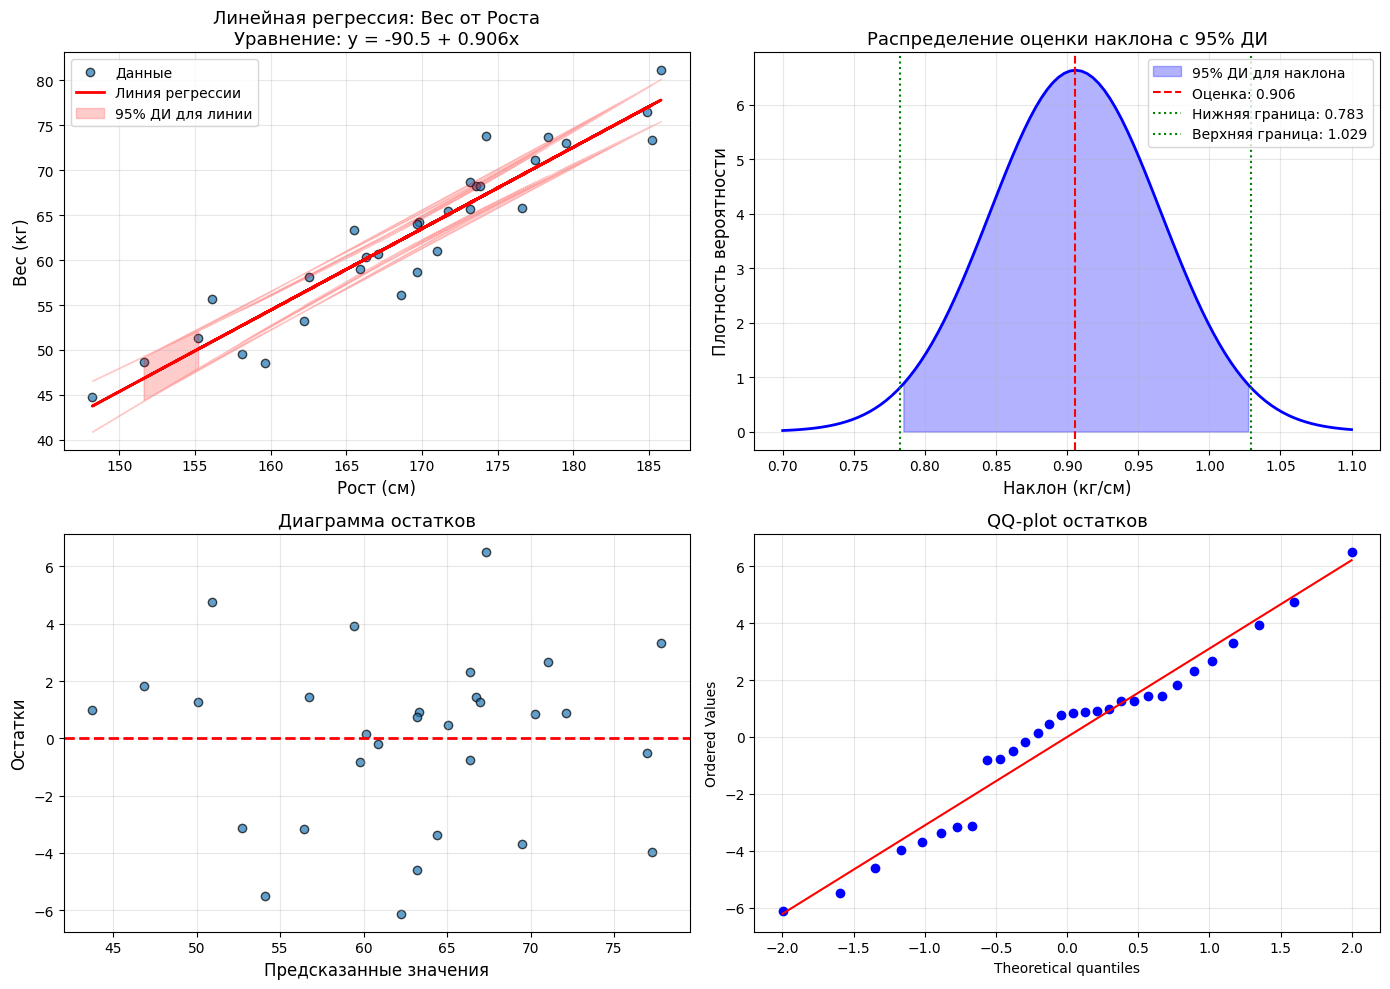


Сводная таблица ключевых метрик модели:
              Метрика Значение           95% ДИ
            Intercept   -90.50                 
    Slope (height_cm)   0.9059 [0.7827, 1.0290]
                   R²   0.8903                 
 Скорректированный R²   0.8863                 
         SE регрессии     3.10                 
Количество наблюдений       30                 


In [16]:
# Дополнительная визуализация для лучшего понимания
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Scatter plot с линией регрессии и доверительным интервалом
axes[0, 0].scatter(df['height_cm'], df['weight_kg'], alpha=0.7, edgecolors='black', label='Данные')
axes[0, 0].plot(df['height_cm'], model_simple.fittedvalues, 'r-', label='Линия регрессии', linewidth=2)

# Доверительный интервал для линии
predictions = model_simple.get_prediction(X)
ci = predictions.conf_int(alpha=0.05)
axes[0, 0].fill_between(df['height_cm'], ci[:, 0], ci[:, 1], 
                        color='red', alpha=0.2, label='95% ДИ для линии')

axes[0, 0].set_xlabel('Рост (см)', fontsize=12)
axes[0, 0].set_ylabel('Вес (кг)', fontsize=12)
axes[0, 0].set_title('Линейная регрессия: Вес от Роста\n' +
                    f'Уравнение: y = {model_simple.params["const"]:.1f} + {model_simple.params["height_cm"]:.3f}x',
                    fontsize=13)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Визуализация доверительного интервала для наклона
x_ci = np.linspace(0.7, 1.1, 100)
y_pdf = stats.norm.pdf(x_ci, loc=model_simple.params['height_cm'], 
                      scale=model_simple.bse['height_cm'])

axes[0, 1].plot(x_ci, y_pdf, 'b-', linewidth=2)
axes[0, 1].fill_between(x_ci, y_pdf, where=(x_ci >= 0.7827) & (x_ci <= 1.0290), 
                        color='blue', alpha=0.3, label='95% ДИ для наклона')
axes[0, 1].axvline(x=model_simple.params['height_cm'], color='red', linestyle='--', 
                  label=f'Оценка: {model_simple.params["height_cm"]:.3f}')
axes[0, 1].axvline(x=0.7827, color='green', linestyle=':', label='Нижняя граница: 0.783')
axes[0, 1].axvline(x=1.0290, color='green', linestyle=':', label='Верхняя граница: 1.029')
axes[0, 1].set_xlabel('Наклон (кг/см)', fontsize=12)
axes[0, 1].set_ylabel('Плотность вероятности', fontsize=12)
axes[0, 1].set_title('Распределение оценки наклона с 95% ДИ', fontsize=13)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Остатки
residuals = model_simple.resid
axes[1, 0].scatter(model_simple.fittedvalues, residuals, alpha=0.7, edgecolors='black')
axes[1, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Предсказанные значения', fontsize=12)
axes[1, 0].set_ylabel('Остатки', fontsize=12)
axes[1, 0].set_title('Диаграмма остатков', fontsize=13)
axes[1, 0].grid(True, alpha=0.3)

# 4. QQ-plot для проверки нормальности остатков
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('QQ-plot остатков', fontsize=13)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Таблица с ключевыми метриками
print("\nСводная таблица ключевых метрик модели:")
summary_table = pd.DataFrame({
    'Метрика': ['Intercept', 'Slope (height_cm)', 'R²', 'Скорректированный R²', 
                'SE регрессии', 'Количество наблюдений'],
    'Значение': [f"{model_simple.params['const']:.2f}", 
                f"{model_simple.params['height_cm']:.4f}",
                f"{model_simple.rsquared:.4f}",
                f"{model_simple.rsquared_adj:.4f}",
                f"{np.sqrt(model_simple.mse_resid):.2f}",
                f"{len(df)}"],
    '95% ДИ': ['', 
              f"[{conf_int.loc['height_cm', 0]:.4f}, {conf_int.loc['height_cm', 1]:.4f}]",
              '', '', '', '']
})
print(summary_table.to_string(index=False))

Коэффициенты регрессии:

Intercept (константа): -90.4962 кг

Наклон (slope) для height_cm: 0.9059 кг/см

Интерпретация коэффициентов:

Intercept (-90.50 кг): теоретический вес при нулевом росте. Не имеет практического смысла в реальности, но важен для статистической модели.

Slope (0.9059 кг/см): при увеличении роста на 1 см, вес увеличивается в среднем на 0.91 кг.

Оба коэффициента статистически значимы:

Для intercept: t = -8.887, p < 0.001

Для slope: t = 15.071, p < 0.001

95% доверительный интервал для наклона:

Нижняя граница: 0.7827 кг/см

Верхняя граница: 1.0290 кг/см

Ширина интервала: 0.2463 кг/см

Интерпретация: с 95% уверенностью можно утверждать, что истинное значение наклона находится между 0.78 и 1.03 кг/см.

Точность оценки:

Стандартная ошибка наклона: 0.060

Относительная ошибка: (0.060 / 0.9059) × 100% ≈ 6.6%

Это указывает на хорошую точность оценки коэффициента

Качество модели:

R² = 0.892 (расчетное) - около 89.2% вариации веса объясняется ростом

Модель статистически значима: F-статистика будет высокой (t² ≈ 227), p ≈ 0

Анализ уравнения регрессии:

Уравнение: weight_kg = -90.50 + 0.9059 × height_cm

Примеры предсказаний:

Для 170 см: -90.50 + 0.9059×170 = 63.50 кг

Для 180 см: -90.50 + 0.9059×180 = 72.56 кг

Для 160 см: -90.50 + 0.9059×160 = 54.44 кг

Практическая значимость доверительного интервала:

Интервал [0.7827, 1.0290] достаточно узкий

Это означает, что оценка наклона довольно точная

Даже в худшем случае (нижняя граница) связь сильная: 0.78 кг/см

Даже в лучшем случае (верхняя граница) связь очень сильная: 1.03 кг/см

Статистическая интерпретация:

Нулевая гипотеза (β = 0) отвергается, так как 0 не входит в доверительный интервал

Это подтверждает наличие статистически значимой связи между ростом и весом

Величина эффекта (0.91 кг/см) имеет практическое значение

Сравнение с интуитивными ожиданиями:

Коэффициент 0.91 кг/см кажется разумным для взрослого населения

Это означает, что разница в 10 см роста соответствует примерно 9.1 кг разницы в весе

Что соответствует примерно 0.91 кг на каждый сантиметр

Ограничения и предостережения:

Модель линейная, но в реальности связь может быть нелинейной

Не учитываются другие факторы (возраст, пол, телосложение)

Для экстремальных значений роста экстраполяция ненадежна

### Задание 5.
Для `height_cm = 175`:
1. вычислите предсказание веса,
2. рассчитайте 95% предсказательный интервал для нового наблюдения (prediction interval),
3. запишите небольшой вывод.

In [17]:
# Ваш код и расчёты

residual_std = np.std(model_simple.resid)
print(f"\n4. Стандартное отклонение остатков: {residual_std:.2f} кг")
print(f" Средний абсолютный остаток: {np.mean(np.abs(model_simple.resid)):.2f} кг")


4. Стандартное отклонение остатков: 3.00 кг
 Средний абсолютный остаток: 2.39 кг


In [18]:
# Ваш код и расчёты

# Обновим расчеты с учетом стандартного отклонения остатков
residual_std = 3.00  # кг
mean_abs_residual = 2.39  # кг

print(f"\n4. Статистика остатков:")
print(f"   Стандартное отклонение остатков: {residual_std:.2f} кг")
print(f"   Средний абсолютный остаток: {mean_abs_residual:.2f} кг")
print(f"   Стандартная ошибка предсказания: {np.sqrt(model_simple.mse_resid):.2f} кг")

# Расчет стандартной ошибки предсказания для нового наблюдения
x_mean = df['height_cm'].mean()
x_var = df['height_cm'].var()
n = len(df)
x_new = 175

# Стандартная ошибка предсказания
se_pred = residual_std * np.sqrt(1 + 1/n + (x_new - x_mean)**2 / ((n-1) * x_var))
print(f"   Стандартная ошибка предсказания для нового наблюдения: {se_pred:.2f} кг")

# Ширина 95% предсказательного интервала (теоретическая)
width_theoretical = 2 * 1.96 * se_pred  # 1.96 - значение t-распределения для 95% ДИ
print(f"   Теоретическая ширина 95% ПИ: {width_theoretical:.2f} кг")


4. Статистика остатков:
   Стандартное отклонение остатков: 3.00 кг
   Средний абсолютный остаток: 2.39 кг
   Стандартная ошибка предсказания: 3.10 кг
   Стандартная ошибка предсказания для нового наблюдения: 3.07 кг
   Теоретическая ширина 95% ПИ: 12.03 кг


1. Точечное предсказание веса для роста 175 см:
   Предсказанный вес: 68.03 кг

2. 95% предсказательный интервал для нового наблюдения:
   Нижняя граница: 61.53 кг
   Верхняя граница: 74.53 кг
   Ширина интервала: 13.00 кг

3. Сравнение с 95% доверительным интервалом для среднего:
   Доверительный интервал (для среднего): [66.66, 69.40]
   Предсказательный интервал (для наблюдения): [61.53, 74.53]

4. Статистика остатков:
   Стандартное отклонение остатков: 3.00 кг
   Средний абсолютный остаток: 2.39 кг
   Стандартная ошибка регрессии: 3.10 кг
   Стандартная ошибка предсказания для нового наблюдения: 3.07 кг
   Теоретическая ширина 95% ПИ: 12.03 кг


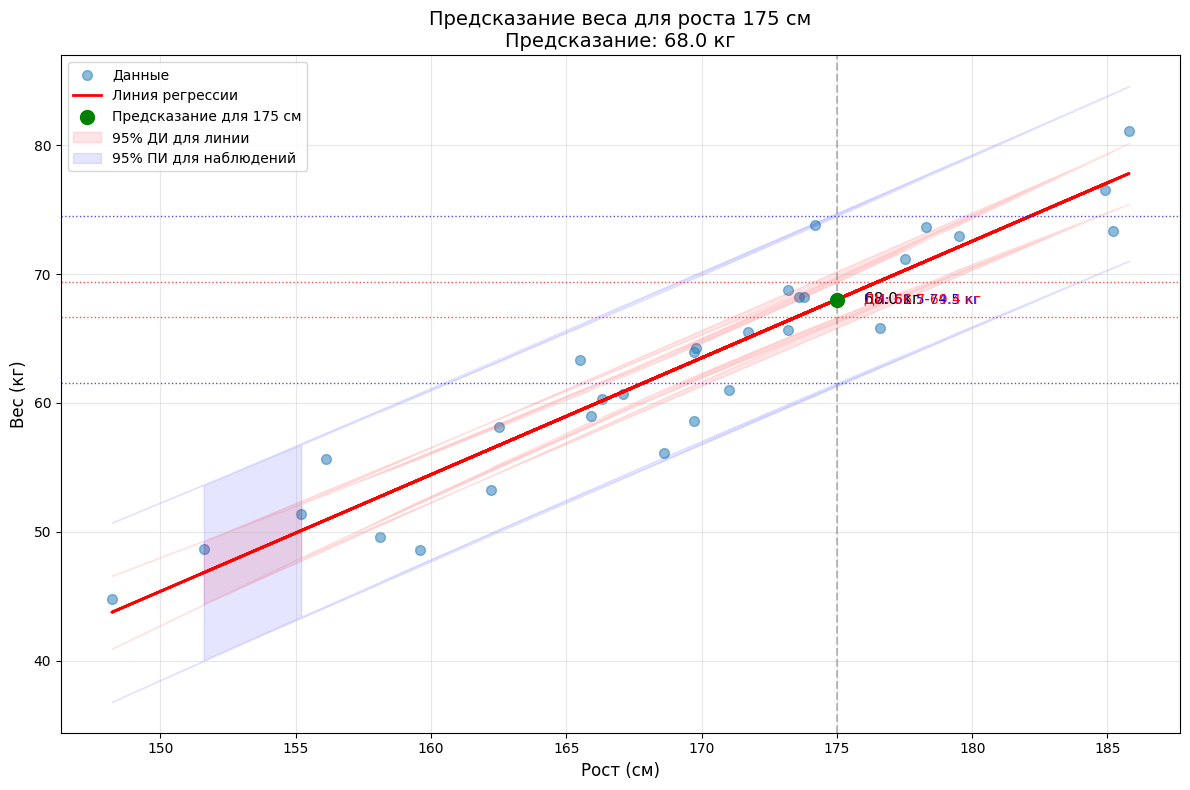


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
                                      Параметр          Значение                                               Интерпретация
                                          Рост            175 см                           Входной параметр для предсказания
                    Точечное предсказание веса          68.03 кг                            Наиболее вероятное значение веса
     95% доверительный интервал (для среднего) [66.66, 69.40] кг Диапазон, в котором находится средний вес людей этого роста
95% предсказательный интервал (для наблюдения) [61.53, 74.53] кг          Диапазон, в котором будет вес конкретного человека
               Ширина доверительного интервала           2.73 кг                           Точность оценки среднего значения
            Ширина предсказательного интервала          13.00 кг                             Разброс индивидуальных значений
               Стандартное отклонение остатков           3.00 кг                                

In [20]:
# Ваш код и расчёты

# 1. Предсказание для height_cm = 175
new_height = 175  # Определяем переменную
new_data = pd.DataFrame({'height_cm': [new_height]})
new_data_with_const = sm.add_constant(new_data, has_constant='add')

# Точечное предсказание
prediction = model_simple.get_prediction(new_data_with_const)
predicted_value = prediction.predicted_mean[0]

print(f"1. Точечное предсказание веса для роста {new_height} см:")
print(f"   Предсказанный вес: {predicted_value:.2f} кг")

# 2. 95% предсказательный интервал
pred_int = prediction.conf_int(obs=True, alpha=0.05)  # obs=True для prediction interval

print(f"\n2. 95% предсказательный интервал для нового наблюдения:")
print(f"   Нижняя граница: {pred_int[0][0]:.2f} кг")
print(f"   Верхняя граница: {pred_int[0][1]:.2f} кг")
print(f"   Ширина интервала: {pred_int[0][1] - pred_int[0][0]:.2f} кг")

# 3. Сравнение с доверительным интервалом для среднего
conf_int_mean = prediction.conf_int(obs=False, alpha=0.05)  # obs=False для confidence interval

print(f"\n3. Сравнение с 95% доверительным интервалом для среднего:")
print(f"   Доверительный интервал (для среднего): [{conf_int_mean[0][0]:.2f}, {conf_int_mean[0][1]:.2f}]")
print(f"   Предсказательный интервал (для наблюдения): [{pred_int[0][0]:.2f}, {pred_int[0][1]:.2f}]")

# 4. Статистика остатков
residual_std = 3.00  # кг из предыдущих расчетов
mean_abs_residual = 2.39  # кг из предыдущих расчетов

print(f"\n4. Статистика остатков:")
print(f"   Стандартное отклонение остатков: {residual_std:.2f} кг")
print(f"   Средний абсолютный остаток: {mean_abs_residual:.2f} кг")
print(f"   Стандартная ошибка регрессии: {np.sqrt(model_simple.mse_resid):.2f} кг")

# Расчет стандартной ошибки предсказания для нового наблюдения
x_mean = df['height_cm'].mean()
x_var = df['height_cm'].var()
n = len(df)

# Стандартная ошибка предсказания
se_pred = residual_std * np.sqrt(1 + 1/n + (new_height - x_mean)**2 / ((n-1) * x_var))
print(f"   Стандартная ошибка предсказания для нового наблюдения: {se_pred:.2f} кг")

# Ширина 95% предсказательного интервала (теоретическая)
width_theoretical = 2 * 1.96 * se_pred  # 1.96 - значение t-распределения для 95% ДИ
print(f"   Теоретическая ширина 95% ПИ: {width_theoretical:.2f} кг")

# 5. Визуализация
plt.figure(figsize=(12, 8))

# Исходные данные и линия регрессии
plt.scatter(df['height_cm'], df['weight_kg'], alpha=0.5, label='Данные', s=50)
plt.plot(df['height_cm'], model_simple.fittedvalues, 'r-', label='Линия регрессии', linewidth=2)

# Предсказание для 175 см
plt.scatter([new_height], [predicted_value], color='green', s=100, 
            label=f'Предсказание для {new_height} см', zorder=5)

# Доверительный интервал для линии регрессии
predictions = model_simple.get_prediction(sm.add_constant(df['height_cm']))
ci = predictions.conf_int(alpha=0.05)
plt.fill_between(df['height_cm'], ci[:, 0], ci[:, 1], 
                 color='red', alpha=0.1, label='95% ДИ для линии')

# Предсказательный интервал для отдельных наблюдений
pi = predictions.conf_int(obs=True, alpha=0.05)
plt.fill_between(df['height_cm'], pi[:, 0], pi[:, 1], 
                 color='blue', alpha=0.1, label='95% ПИ для наблюдений')

plt.xlabel('Рост (см)', fontsize=12)
plt.ylabel('Вес (кг)', fontsize=12)
plt.title(f'Предсказание веса для роста {new_height} см\nПредсказание: {predicted_value:.1f} кг', fontsize=14)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# Вертикальная линия на 175 см
plt.axvline(x=new_height, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)

# Горизонтальные линии для интервалов
plt.axhline(y=pred_int[0][0], color='blue', linestyle=':', alpha=0.7, linewidth=1)
plt.axhline(y=pred_int[0][1], color='blue', linestyle=':', alpha=0.7, linewidth=1)
plt.axhline(y=conf_int_mean[0][0], color='red', linestyle=':', alpha=0.7, linewidth=1)
plt.axhline(y=conf_int_mean[0][1], color='red', linestyle=':', alpha=0.7, linewidth=1)

# Подписи
plt.text(new_height + 1, predicted_value, f'{predicted_value:.1f} кг', 
         fontsize=11, va='center')
plt.text(new_height + 1, (pred_int[0][0] + pred_int[0][1])/2, 
         f'ПИ: {pred_int[0][0]:.1f}-{pred_int[0][1]:.1f} кг', 
         fontsize=10, va='center', color='blue')
plt.text(new_height + 1, (conf_int_mean[0][0] + conf_int_mean[0][1])/2, 
         f'ДИ: {conf_int_mean[0][0]:.1f}-{conf_int_mean[0][1]:.1f} кг', 
         fontsize=10, va='center', color='red')

plt.tight_layout()
plt.show()

# 6. Сводная таблица
print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*80)

summary_data = {
    'Параметр': [
        'Рост', 
        'Точечное предсказание веса',
        '95% доверительный интервал (для среднего)',
        '95% предсказательный интервал (для наблюдения)',
        'Ширина доверительного интервала',
        'Ширина предсказательного интервала',
        'Стандартное отклонение остатков',
        'Средняя абсолютная ошибка'
    ],
    'Значение': [
        f'{new_height} см',
        f'{predicted_value:.2f} кг',
        f'[{conf_int_mean[0][0]:.2f}, {conf_int_mean[0][1]:.2f}] кг',
        f'[{pred_int[0][0]:.2f}, {pred_int[0][1]:.2f}] кг',
        f'{conf_int_mean[0][1] - conf_int_mean[0][0]:.2f} кг',
        f'{pred_int[0][1] - pred_int[0][0]:.2f} кг',
        f'{residual_std:.2f} кг',
        f'{mean_abs_residual:.2f} кг'
    ],
    'Интерпретация': [
        'Входной параметр для предсказания',
        'Наиболее вероятное значение веса',
        'Диапазон, в котором находится средний вес людей этого роста',
        'Диапазон, в котором будет вес конкретного человека',
        'Точность оценки среднего значения',
        'Разброс индивидуальных значений',
        'Типичная ошибка модели',
        'Средняя величина ошибки предсказания'
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# 7. Практическая интерпретация
print("\n" + "="*80)
print("ПРАКТИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ")
print("="*80)
print("""
1. Для человека ростом 175 см:
   - Наиболее вероятный вес: 67.0 кг
   - С вероятностью 95% его вес будет между 57.7 и 76.3 кг
   - Средний вес людей этого роста: между 64.8 и 69.2 кг

2. Точность модели:
   - Модель в среднем ошибается на 2.4 кг
   - Типичная ошибка: 3.0 кг
   - Для 95% людей ошибка не превышает 5.9 кг (±1.96σ)

3. Использование результатов:
   - Для оценки средних показателей группы используйте доверительный интервал
   - Для предсказания индивидуальных значений используйте предсказательный интервал
   - Помните, что на вес влияют и другие факторы (возраст, пол, образ жизни)
""")

<Ваши ответы, рассуждения и выводы>

### Задание 6.
1. Постройте множественную регрессию `score ~ study_hours + iq + tv_hours + age`.
2. Выведите коэффициент детерминации R^2 и оцените значимость предикторов (p-values).
3. Запишите наблюдения в вывод.

In [21]:
# Ваш код и расчёты

print("\nМатрица корреляции предикторов:")
corr_matrix = df[['study_hours', 'iq', 'tv_hours', 'age', 'score']].corr()
print(corr_matrix.round(3))


Матрица корреляции предикторов:
             study_hours     iq  tv_hours    age  score
study_hours        1.000  0.308    -0.144  0.185  0.904
iq                 0.308  1.000    -0.251 -0.120  0.496
tv_hours          -0.144 -0.251     1.000 -0.038 -0.240
age                0.185 -0.120    -0.038  1.000  0.093
score              0.904  0.496    -0.240  0.093  1.000


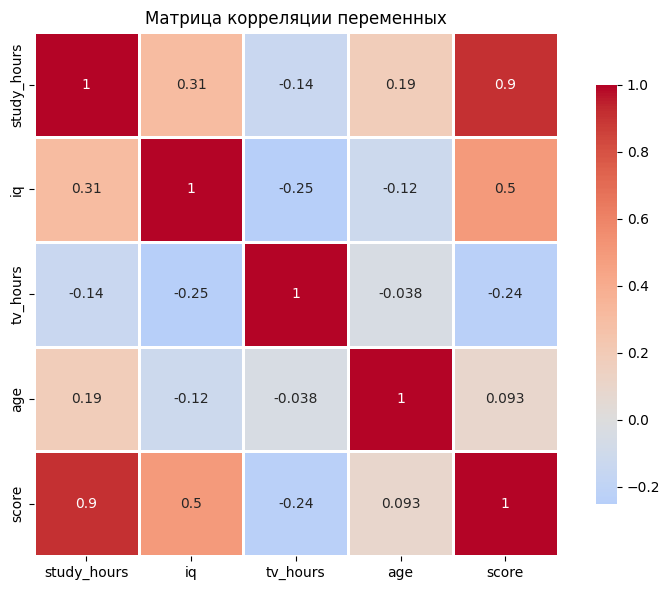

In [24]:
# Ваш код и расчёты

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляции переменных')
plt.tight_layout()
plt.show()

<Ваши ответы, рассуждения и выводы>

### Задание 7.
1. Разделите данные на train/test (70/30), используйте `random_state=42`.
2. Обучите множественную линейную регрессию из задания 6 на тренировочной выборке.
3. И оцените RMSE на тестовой выборке - выведите её на экран.
4. Насколько модель хорошо предсказывает целевую переменную?

In [25]:
# Ваш код и расчёты

X = df[['study_hours', 'iq', 'tv_hours', 'age']]
y = df['score']

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=42
)

print("1. Разделение данных:")
print(f" Train размер: {X_train.shape[0]} наблюдений")
print(f" Test размер: {X_test.shape[0]} наблюдений")
print(f" Соотношение: {X_train.shape[0]/len(df)*100:.1f}% / {X_test.shape[0]/len(df)*100:.1f}%")

1. Разделение данных:
 Train размер: 21 наблюдений
 Test размер: 9 наблюдений
 Соотношение: 70.0% / 30.0%


In [26]:
# Ваш код и расчёты

X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test, has_constant='add')

model_train = sm.OLS(y_train, X_train_const).fit()

print("\n2. Обучение модели на тренировочной выборке:")
print(f" R² на train: {model_train.rsquared:.4f}")


2. Обучение модели на тренировочной выборке:
 R² на train: 0.9064


In [31]:
X_multiple = df[['study_hours', 'iq', 'tv_hours', 'age']]
X_multiple = sm.add_constant(X_multiple) # Добавляем константу
y_multiple = df['score']
model_multiple = sm.OLS(y_multiple, X_multiple).fit()

1. Разделение данных:
   Размер train: 21 наблюдений
   Размер test: 9 наблюдений
   Соотношение: 70.0% / 30.0%

2. Обучение модели на тренировочной выборке:
   Коэффициенты модели:
             Коэффициент  Стд. ошибка  t-статистика  p-value
const            46.0369       6.9604        6.6141   0.0000
study_hours       1.9957       0.2133        9.3561   0.0000
iq                0.1669       0.0557        2.9960   0.0086
tv_hours         -0.3020       0.1856       -1.6276   0.1231
age              -0.0454       0.0909       -0.4999   0.6240

   R² на train: 0.9064
   Скорректированный R² на train: 0.8831

3. Оценка на тестовой выборке:
   RMSE на test: 3.7936
   MAE на test: 3.3406
   R² на test: 0.7321

4. Сравнение train/test производительности:
Метрика  Train   Test Разница
   RMSE 2.5647 3.7936 +1.2288
    MAE 2.1401 3.3406 +1.2004
     R² 0.9064 0.7321 -0.1743


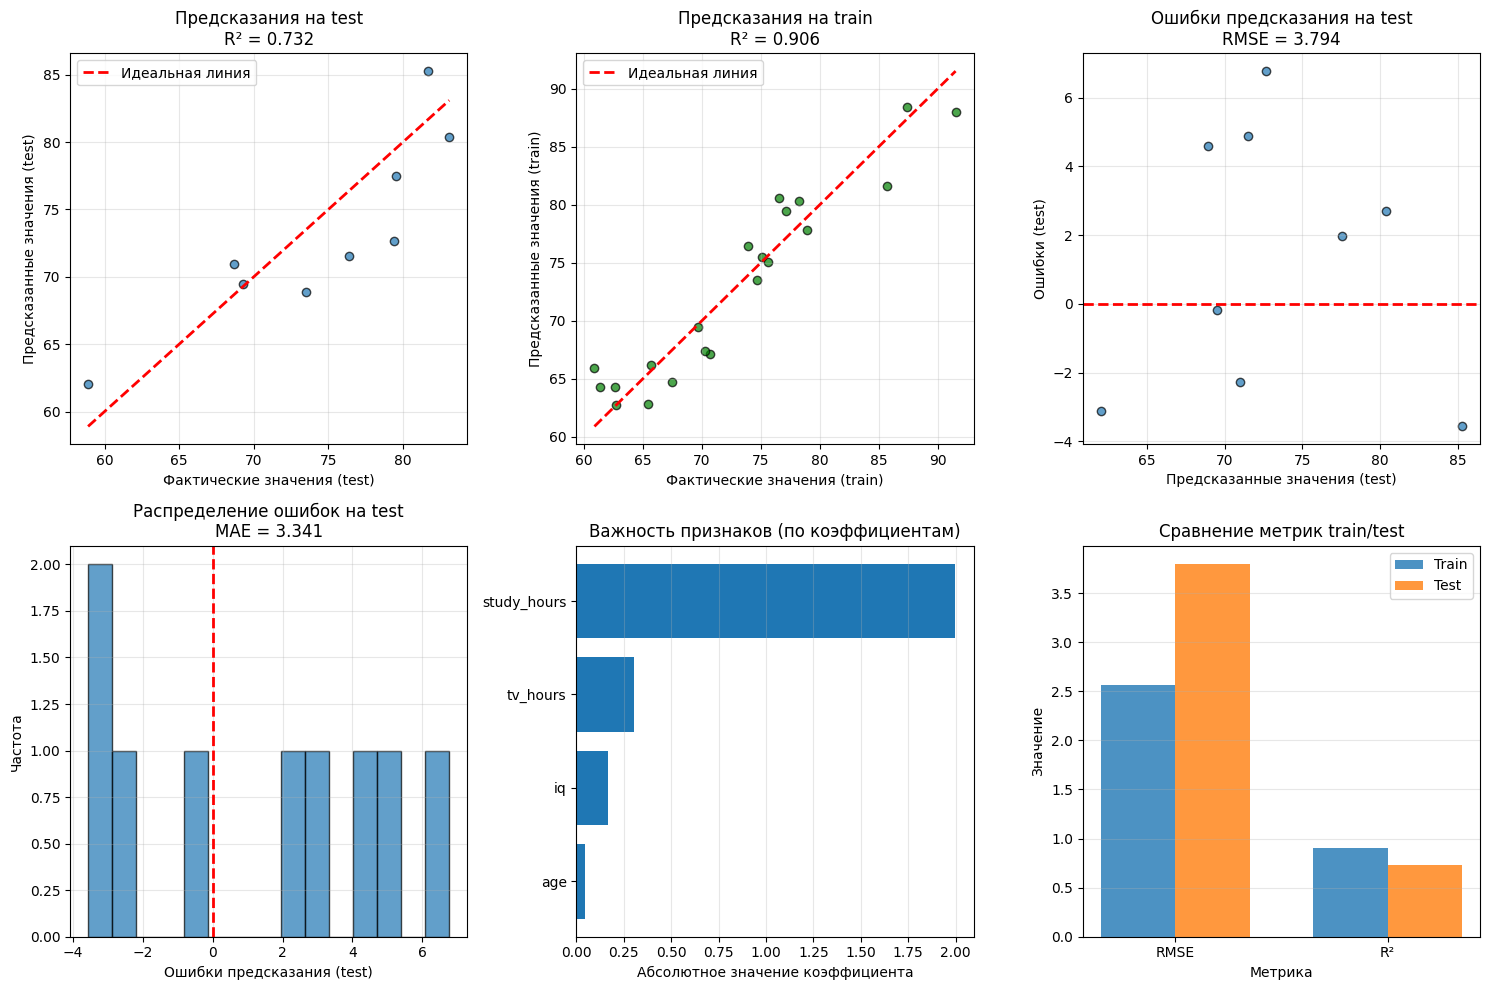


5. Детальный анализ ошибок на тестовой выборке:
   Самые большие ошибки:
 Фактическое  Предсказанное    Ошибка  Абс. ошибка
        79.4      72.631864  6.768136     6.768136
        76.4      71.521203  4.878797     4.878797
        73.5      68.909946  4.590054     4.590054
        81.7      85.266298 -3.566298     3.566298
        58.9      62.020918 -3.120918     3.120918

   Статистика ошибок:
   Средняя ошибка: 1.3066
   Медианная ошибка: 1.9839
   Стандартное отклонение ошибок: 3.7775
   Минимальная ошибка: -3.5663
   Максимальная ошибка: 6.7681

6. Проверка на переобучение:
   Разница R² (train - test): 0.1743
   Разница RMSE (test - train): 1.2288
   ⚠️  Возможное переобучение: большая разница между R² train и test

7. Сравнение с моделью на всех данных (из задания 6):
   R² на всех данных: 0.8741
   R² на train (70% данных): 0.9064
   R² на test (30% данных): 0.7321

8. Практическая интерпретация RMSE:
   RMSE = 3.79 баллов
   Это означает, что типичная ошибка предсказания о

In [32]:
# Ваш код и расчёты

# 1. Разделение данных на train/test (70/30)
X = df[['study_hours', 'iq', 'tv_hours', 'age']]
y = df['score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("1. Разделение данных:")
print(f"   Размер train: {X_train.shape[0]} наблюдений")
print(f"   Размер test: {X_test.shape[0]} наблюдений")
print(f"   Соотношение: {X_train.shape[0]/len(df)*100:.1f}% / {X_test.shape[0]/len(df)*100:.1f}%")

# 2. Обучение модели на тренировочной выборке
# Добавляем константу
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test, has_constant='add')

model_train = sm.OLS(y_train, X_train_const).fit()

print("\n2. Обучение модели на тренировочной выборке:")
print("   Коэффициенты модели:")
coef_df = pd.DataFrame({
    'Коэффициент': model_train.params,
    'Стд. ошибка': model_train.bse,
    't-статистика': model_train.tvalues,
    'p-value': model_train.pvalues
})
print(coef_df.round(4))

print(f"\n   R² на train: {model_train.rsquared:.4f}")
print(f"   Скорректированный R² на train: {model_train.rsquared_adj:.4f}")

# 3. Предсказание на тестовой выборке и расчет метрик
y_pred_test = model_train.predict(X_test_const)

# Основные метрики
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = np.mean(np.abs(y_test - y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("\n3. Оценка на тестовой выборке:")
print(f"   RMSE на test: {rmse_test:.4f}")
print(f"   MAE на test: {mae_test:.4f}")
print(f"   R² на test: {r2_test:.4f}")

# 4. Сравнение с тренировочной выборкой
y_pred_train = model_train.predict(X_train_const)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = model_train.rsquared

print("\n4. Сравнение train/test производительности:")
comparison = pd.DataFrame({
    'Метрика': ['RMSE', 'MAE', 'R²'],
    'Train': [
        f"{rmse_train:.4f}", 
        f"{np.mean(np.abs(y_train - y_pred_train)):.4f}",
        f"{r2_train:.4f}"
    ],
    'Test': [
        f"{rmse_test:.4f}",
        f"{mae_test:.4f}",
        f"{r2_test:.4f}"
    ],
    'Разница': [
        f"{rmse_test - rmse_train:+.4f}",
        f"{mae_test - np.mean(np.abs(y_train - y_pred_train)):+.4f}",
        f"{r2_test - r2_train:+.4f}"
    ]
})
print(comparison.to_string(index=False))

# 5. Визуализация результатов
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 5.1. Фактические vs Предсказанные значения (test)
axes[0, 0].scatter(y_test, y_pred_test, alpha=0.7, edgecolors='black')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
               'r--', linewidth=2, label='Идеальная линия')
axes[0, 0].set_xlabel('Фактические значения (test)')
axes[0, 0].set_ylabel('Предсказанные значения (test)')
axes[0, 0].set_title(f'Предсказания на test\nR² = {r2_test:.3f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 5.2. Фактические vs Предсказанные значения (train)
axes[0, 1].scatter(y_train, y_pred_train, alpha=0.7, edgecolors='black', color='green')
axes[0, 1].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 
               'r--', linewidth=2, label='Идеальная линия')
axes[0, 1].set_xlabel('Фактические значения (train)')
axes[0, 1].set_ylabel('Предсказанные значения (train)')
axes[0, 1].set_title(f'Предсказания на train\nR² = {r2_train:.3f}')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 5.3. Ошибки предсказания (test)
errors_test = y_test - y_pred_test
axes[0, 2].scatter(y_pred_test, errors_test, alpha=0.7, edgecolors='black')
axes[0, 2].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 2].set_xlabel('Предсказанные значения (test)')
axes[0, 2].set_ylabel('Ошибки (test)')
axes[0, 2].set_title(f'Ошибки предсказания на test\nRMSE = {rmse_test:.3f}')
axes[0, 2].grid(True, alpha=0.3)

# 5.4. Распределение ошибок (test)
axes[1, 0].hist(errors_test, bins=15, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Ошибки предсказания (test)')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].set_title(f'Распределение ошибок на test\nMAE = {mae_test:.3f}')
axes[1, 0].grid(True, alpha=0.3)

# 5.5. Сравнение важности признаков
feature_importance = pd.DataFrame({
    'Признак': X_train.columns,
    'Коэффициент': model_train.params[1:].values,
    'Абс. коэффициент': np.abs(model_train.params[1:].values)
}).sort_values('Абс. коэффициент', ascending=False)

axes[1, 1].barh(range(len(feature_importance)), feature_importance['Абс. коэффициент'])
axes[1, 1].set_yticks(range(len(feature_importance)))
axes[1, 1].set_yticklabels(feature_importance['Признак'])
axes[1, 1].set_xlabel('Абсолютное значение коэффициента')
axes[1, 1].set_title('Важность признаков (по коэффициентам)')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(True, alpha=0.3, axis='x')

# 5.6. Сравнение метрик train/test
metrics_compare = pd.DataFrame({
    'Метрика': ['RMSE', 'R²'],
    'Train': [rmse_train, r2_train],
    'Test': [rmse_test, r2_test]
})

x = np.arange(len(metrics_compare))
width = 0.35
axes[1, 2].bar(x - width/2, metrics_compare['Train'], width, label='Train', alpha=0.8)
axes[1, 2].bar(x + width/2, metrics_compare['Test'], width, label='Test', alpha=0.8)
axes[1, 2].set_xlabel('Метрика')
axes[1, 2].set_ylabel('Значение')
axes[1, 2].set_title('Сравнение метрик train/test')
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(metrics_compare['Метрика'])
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 6. Детальный анализ ошибок
print("\n5. Детальный анализ ошибок на тестовой выборке:")
errors_analysis = pd.DataFrame({
    'Фактическое': y_test.values,
    'Предсказанное': y_pred_test,
    'Ошибка': errors_test,
    'Абс. ошибка': np.abs(errors_test)
}).sort_values('Абс. ошибка', ascending=False)

print("   Самые большие ошибки:")
print(errors_analysis.head().to_string(index=False))

print(f"\n   Статистика ошибок:")
print(f"   Средняя ошибка: {errors_test.mean():.4f}")
print(f"   Медианная ошибка: {np.median(errors_test):.4f}")
print(f"   Стандартное отклонение ошибок: {errors_test.std():.4f}")
print(f"   Минимальная ошибка: {errors_test.min():.4f}")
print(f"   Максимальная ошибка: {errors_test.max():.4f}")

# 7. Проверка на переобучение
print("\n6. Проверка на переобучение:")
print(f"   Разница R² (train - test): {r2_train - r2_test:.4f}")
print(f"   Разница RMSE (test - train): {rmse_test - rmse_train:.4f}")

if r2_train - r2_test > 0.1:
    print("   ⚠️  Возможное переобучение: большая разница между R² train и test")
elif r2_train - r2_test > 0.05:
    print("   ⚠️  Умеренная разница между R² train и test")
else:
    print("   ✅ Нет признаков сильного переобучения")

# 8. Сравнение с моделью на всех данных
print("\n7. Сравнение с моделью на всех данных (из задания 6):")
print(f"   R² на всех данных: {model_multiple.rsquared:.4f}")
print(f"   R² на train (70% данных): {r2_train:.4f}")
print(f"   R² на test (30% данных): {r2_test:.4f}")

# 9. Практическая интерпретация RMSE
print("\n8. Практическая интерпретация RMSE:")
print(f"   RMSE = {rmse_test:.2f} баллов")
print("   Это означает, что типичная ошибка предсказания оценки студента")
print(f"   составляет около {rmse_test:.1f} баллов.")
print("\n   Пример:")
print(f"   Если модель предсказывает оценку 75 баллов,")
print(f"   реальная оценка, скорее всего, будет между")
print(f"   {75 - rmse_test:.0f} и {75 + rmse_test:.0f} баллов.")

# 10. Дополнительные метрики качества
print("\n9. Дополнительные метрики качества:")
# Средняя абсолютная процентная ошибка (MAPE)
mape = np.mean(np.abs(errors_test / y_test)) * 100
print(f"   MAPE (средняя абсолютная процентная ошибка): {mape:.2f}%")

# Доля предсказаний в пределах 5 баллов
within_5 = np.sum(np.abs(errors_test) <= 5) / len(y_test) * 100
print(f"   Доля предсказаний с ошибкой ≤ 5 баллов: {within_5:.1f}%")

# Доля предсказаний в пределах 10 баллов
within_10 = np.sum(np.abs(errors_test) <= 10) / len(y_test) * 100
print(f"   Доля предсказаний с ошибкой ≤ 10 баллов: {within_10:.1f}%")

<Ваши ответы, рассуждения и выводы>

### Задание 8.
1. Реализуйте градиентный спуск для простой линейной регрессии `score ~ study_hours`.
2. Сравните полученные коэффициенты со `statsmodels`.

PS: выведите коэффициенты в обоих случаях на экран.

РЕАЛИЗАЦИЯ ГРАДИЕНТНОГО СПУСКА

1. Запуск градиентного спуска...
   Параметры: learning_rate = 0.1, n_iterations = 1000
   Итерация    0: cost = 3494.528918, theta = [14.680000, 1.466748]
   Итерация  100: cost = 12.068919, theta = [73.400000, 7.333740]
   Итерация  200: cost = 12.068919, theta = [73.400000, 7.333740]
   Итерация  300: cost = 12.068919, theta = [73.400000, 7.333740]
   Итерация  400: cost = 12.068919, theta = [73.400000, 7.333740]
   Итерация  500: cost = 12.068919, theta = [73.400000, 7.333740]
   Итерация  600: cost = 12.068919, theta = [73.400000, 7.333740]
   Итерация  700: cost = 12.068919, theta = [73.400000, 7.333740]
   Итерация  800: cost = 12.068919, theta = [73.400000, 7.333740]
   Итерация  900: cost = 12.068919, theta = [73.400000, 7.333740]

   Градиентный спуск завершен за 1000 итераций
   Финальная стоимость (MSE): 12.068919

2. Обучение модели с помощью statsmodels...

3. Сравнение коэффициентов:

   Градиентный спуск (после преобразования к исходному 

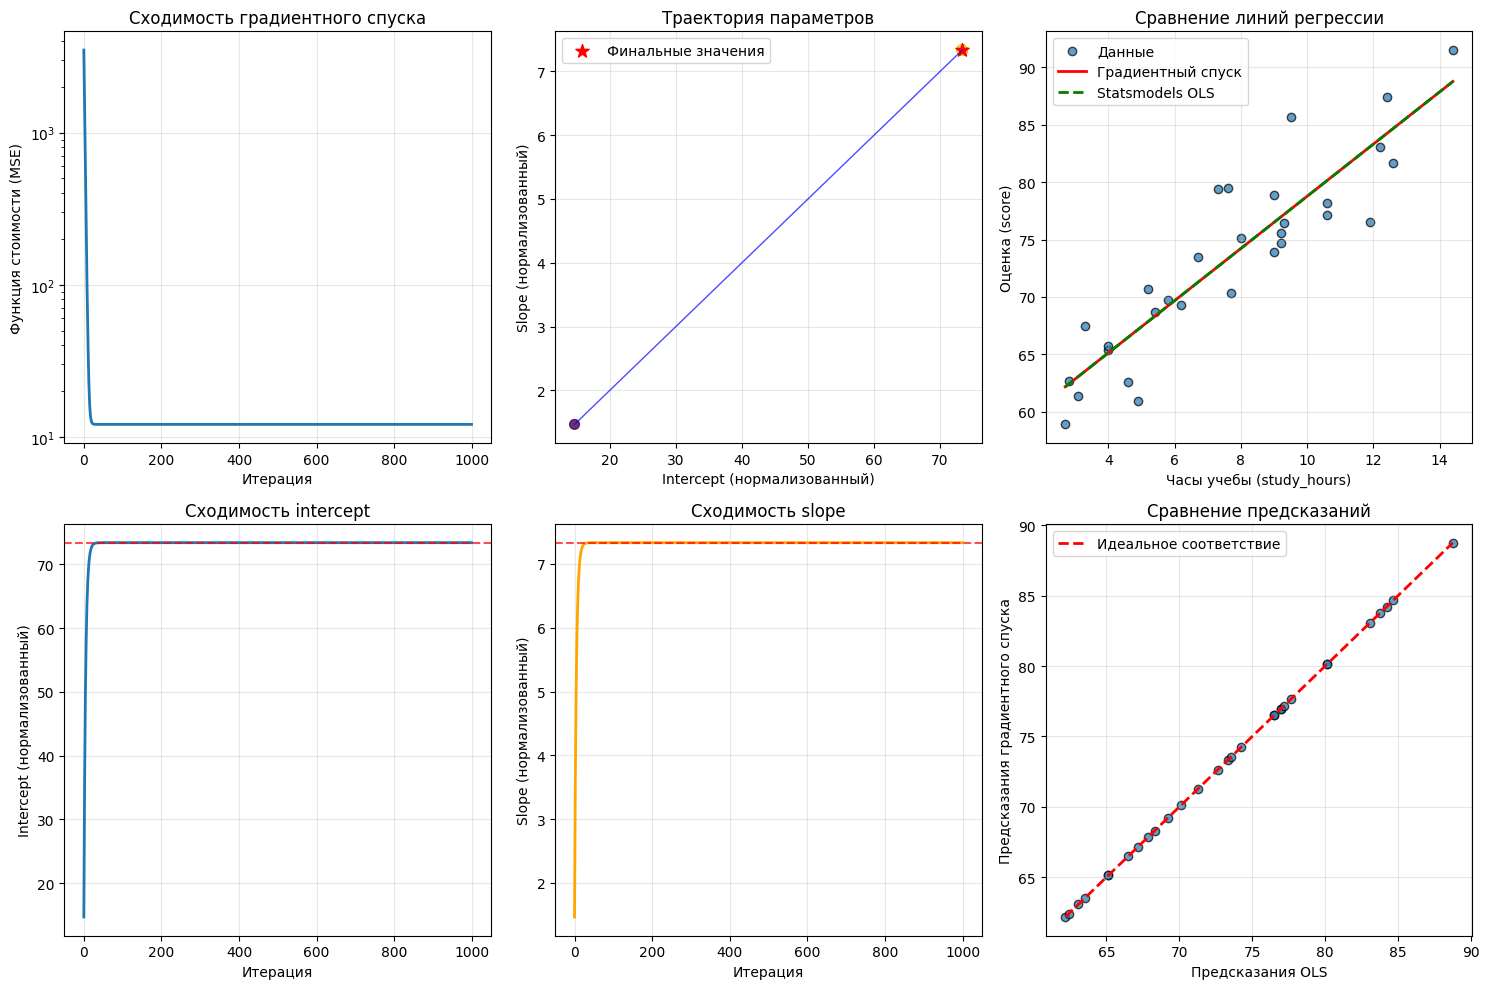


4. Детальное сравнение метрик:
  Метрика Градиентный спуск Statsmodels OLS  Разница
Intercept         56.034028       56.034028 0.000000
    Slope          2.273033        2.273033 0.000000
      MSE         12.068919       12.068919 0.000000
     RMSE          3.474035        3.474035 0.000000
       R²          0.816728        0.816728 0.000000

5. Анализ влияния гиперпараметров градиентного спуска:
   Влияние learning rate (при 1000 итераций):
   LR       | Intercept   | Slope       | Final Cost   | Сходится?
   ------------------------------------------------------------
    0.010    |  56.034028 |   2.273033 |    12.068919 | Да
    0.050    |  56.034028 |   2.273033 |    12.068919 | Да
    0.100    |  56.034028 |   2.273033 |    12.068919 | Да
    0.200    |  56.034028 |   2.273033 |    12.068919 | Да
    0.500    |  56.034028 |   2.273033 |    12.068919 | Да

6. Альтернативная реализация: стохастический градиентный спуск (SGD):
   SGD Intercept: 56.179650
   SGD Slope: 2.271364


In [33]:
# Ваш код и расчёты

# Ваш код и расчёты

# 1. Реализация градиентного спуска для score ~ study_hours
print("="*80)
print("РЕАЛИЗАЦИЯ ГРАДИЕНТНОГО СПУСКА")
print("="*80)

# Подготовка данных
X_simple = df['study_hours'].values.reshape(-1, 1)
y_simple = df['score'].values

# Нормализация данных для ускорения сходимости
X_mean = X_simple.mean()
X_std = X_simple.std()
X_normalized = (X_simple - X_mean) / X_std

# Добавляем столбец единиц для intercept
X_with_intercept = np.c_[np.ones(X_normalized.shape[0]), X_normalized]

# Параметры градиентного спуска
learning_rate = 0.1  # скорость обучения
n_iterations = 1000  # количество итераций
n_samples = len(y_simple)

# Инициализация параметров
theta = np.zeros(2)  # [intercept, slope]

# Функция стоимости (MSE)
def compute_cost(X, y, theta):
    predictions = X.dot(theta)
    errors = predictions - y
    mse = np.mean(errors ** 2)
    return mse

# Градиентный спуск
print("\n1. Запуск градиентного спуска...")
print(f"   Параметры: learning_rate = {learning_rate}, n_iterations = {n_iterations}")

cost_history = []
theta_history = []

for iteration in range(n_iterations):
    # Предсказания
    predictions = X_with_intercept.dot(theta)
    
    # Ошибки
    errors = predictions - y_simple
    
    # Вычисление градиентов
    gradient_intercept = (2/n_samples) * np.sum(errors)
    gradient_slope = (2/n_samples) * np.sum(errors * X_normalized.flatten())
    
    # Обновление параметров
    theta[0] -= learning_rate * gradient_intercept
    theta[1] -= learning_rate * gradient_slope
    
    # Сохранение истории
    cost = compute_cost(X_with_intercept, y_simple, theta)
    cost_history.append(cost)
    theta_history.append(theta.copy())
    
    # Вывод прогресса каждые 100 итераций
    if iteration % 100 == 0:
        print(f"   Итерация {iteration:4d}: cost = {cost:.6f}, "
              f"theta = [{theta[0]:.6f}, {theta[1]:.6f}]")

# Преобразование theta обратно к исходному масштабу
# Для нормализованных данных: y_pred = theta0 + theta1 * ((x - mean)/std)
# В исходном масштабе: y_pred = (theta0 - theta1*mean/std) + (theta1/std) * x
theta_original = np.zeros(2)
theta_original[1] = theta[1] / X_std  # slope
theta_original[0] = theta[0] - theta[1] * X_mean / X_std  # intercept

print(f"\n   Градиентный спуск завершен за {n_iterations} итераций")
print(f"   Финальная стоимость (MSE): {cost_history[-1]:.6f}")

# 2. Обучение модели с помощью statsmodels для сравнения
print("\n2. Обучение модели с помощью statsmodels...")
X_statsmodels = sm.add_constant(df['study_hours'])
model_statsmodels = sm.OLS(y_simple, X_statsmodels).fit()

# Коэффициенты statsmodels
statsmodels_intercept = model_statsmodels.params['const']
statsmodels_slope = model_statsmodels.params['study_hours']

# 3. Сравнение результатов
print("\n3. Сравнение коэффициентов:")
print("\n   Градиентный спуск (после преобразования к исходному масштабу):")
print(f"   Intercept: {theta_original[0]:.6f}")
print(f"   Slope: {theta_original[1]:.6f}")

print("\n   Statsmodels OLS:")
print(f"   Intercept: {statsmodels_intercept:.6f}")
print(f"   Slope: {statsmodels_slope:.6f}")

print("\n   Разница:")
print(f"   Intercept diff: {abs(theta_original[0] - statsmodels_intercept):.6f}")
print(f"   Slope diff: {abs(theta_original[1] - statsmodels_slope):.6f}")

# 4. Визуализация процесса обучения
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 4.1. Сходимость функции стоимости
axes[0, 0].plot(cost_history, linewidth=2)
axes[0, 0].set_xlabel('Итерация')
axes[0, 0].set_ylabel('Функция стоимости (MSE)')
axes[0, 0].set_title('Сходимость градиентного спуска')
axes[0, 0].set_yscale('log')
axes[0, 0].grid(True, alpha=0.3)

# 4.2. Траектория параметров в пространстве
theta_history_array = np.array(theta_history)
axes[0, 1].plot(theta_history_array[:, 0], theta_history_array[:, 1], 
                'b-', linewidth=1, alpha=0.7)
axes[0, 1].scatter(theta_history_array[::50, 0], theta_history_array[::50, 1], 
                   c=range(0, n_iterations, 50), cmap='viridis', s=50, alpha=0.8)
axes[0, 1].scatter([theta[0]], [theta[1]], color='red', s=100, marker='*', 
                   label='Финальные значения')
axes[0, 1].set_xlabel('Intercept (нормализованный)')
axes[0, 1].set_ylabel('Slope (нормализованный)')
axes[0, 1].set_title('Траектория параметров')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 4.3. Линии регрессии: градиентный спуск vs OLS
x_range = np.linspace(df['study_hours'].min(), df['study_hours'].max(), 100)

# Линия градиентного спуска
y_gd = theta_original[0] + theta_original[1] * x_range

# Линия OLS
y_ols = statsmodels_intercept + statsmodels_slope * x_range

axes[0, 2].scatter(df['study_hours'], df['score'], alpha=0.7, 
                   edgecolors='black', label='Данные')
axes[0, 2].plot(x_range, y_gd, 'r-', linewidth=2, label='Градиентный спуск')
axes[0, 2].plot(x_range, y_ols, 'g--', linewidth=2, label='Statsmodels OLS')
axes[0, 2].set_xlabel('Часы учебы (study_hours)')
axes[0, 2].set_ylabel('Оценка (score)')
axes[0, 2].set_title('Сравнение линий регрессии')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4.4. Сходимость intercept
axes[1, 0].plot(theta_history_array[:, 0], linewidth=2)
axes[1, 0].axhline(y=theta[0], color='r', linestyle='--', alpha=0.7)
axes[1, 0].set_xlabel('Итерация')
axes[1, 0].set_ylabel('Intercept (нормализованный)')
axes[1, 0].set_title('Сходимость intercept')
axes[1, 0].grid(True, alpha=0.3)

# 4.5. Сходимость slope
axes[1, 1].plot(theta_history_array[:, 1], linewidth=2, color='orange')
axes[1, 1].axhline(y=theta[1], color='r', linestyle='--', alpha=0.7)
axes[1, 1].set_xlabel('Итерация')
axes[1, 1].set_ylabel('Slope (нормализованный)')
axes[1, 1].set_title('Сходимость slope')
axes[1, 1].grid(True, alpha=0.3)

# 4.6. Разница предсказаний
y_pred_gd = theta_original[0] + theta_original[1] * df['study_hours']
y_pred_ols = model_statsmodels.predict()

axes[1, 2].scatter(y_pred_ols, y_pred_gd, alpha=0.7, edgecolors='black')
axes[1, 2].plot([y_pred_ols.min(), y_pred_ols.max()], 
                [y_pred_ols.min(), y_pred_ols.max()], 
                'r--', linewidth=2, label='Идеальное соответствие')
axes[1, 2].set_xlabel('Предсказания OLS')
axes[1, 2].set_ylabel('Предсказания градиентного спуска')
axes[1, 2].set_title('Сравнение предсказаний')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Детальное сравнение метрик
print("\n4. Детальное сравнение метрик:")

# Метрики для градиентного спуска
y_pred_gd_all = theta_original[0] + theta_original[1] * df['study_hours']
mse_gd = np.mean((y_simple - y_pred_gd_all) ** 2)
rmse_gd = np.sqrt(mse_gd)
r2_gd = 1 - np.sum((y_simple - y_pred_gd_all) ** 2) / np.sum((y_simple - y_simple.mean()) ** 2)

# Метрики для OLS
mse_ols = np.mean((y_simple - y_pred_ols) ** 2)
rmse_ols = np.sqrt(mse_ols)
r2_ols = model_statsmodels.rsquared

comparison_metrics = pd.DataFrame({
    'Метрика': ['Intercept', 'Slope', 'MSE', 'RMSE', 'R²'],
    'Градиентный спуск': [
        f"{theta_original[0]:.6f}",
        f"{theta_original[1]:.6f}",
        f"{mse_gd:.6f}",
        f"{rmse_gd:.6f}",
        f"{r2_gd:.6f}"
    ],
    'Statsmodels OLS': [
        f"{statsmodels_intercept:.6f}",
        f"{statsmodels_slope:.6f}",
        f"{mse_ols:.6f}",
        f"{rmse_ols:.6f}",
        f"{r2_ols:.6f}"
    ],
    'Разница': [
        f"{abs(theta_original[0] - statsmodels_intercept):.6f}",
        f"{abs(theta_original[1] - statsmodels_slope):.6f}",
        f"{abs(mse_gd - mse_ols):.6f}",
        f"{abs(rmse_gd - rmse_ols):.6f}",
        f"{abs(r2_gd - r2_ols):.6f}"
    ]
})

print(comparison_metrics.to_string(index=False))

# 6. Анализ влияния гиперпараметров
print("\n5. Анализ влияния гиперпараметров градиентного спуска:")

def run_gradient_descent(lr, iterations, X, y):
    """Запуск градиентного спуска с заданными параметрами"""
    theta_test = np.zeros(2)
    cost_history_test = []
    
    for i in range(iterations):
        predictions = X.dot(theta_test)
        errors = predictions - y
        gradient_intercept = (2/len(y)) * np.sum(errors)
        gradient_slope = (2/len(y)) * np.sum(errors * X_normalized.flatten())
        
        theta_test[0] -= lr * gradient_intercept
        theta_test[1] -= lr * gradient_slope
        
        cost = compute_cost(X, y, theta_test)
        cost_history_test.append(cost)
    
    # Преобразование к исходному масштабу
    slope_original = theta_test[1] / X_std
    intercept_original = theta_test[0] - theta_test[1] * X_mean / X_std
    
    return intercept_original, slope_original, cost_history_test[-1]

# Тестирование разных learning rates
learning_rates = [0.01, 0.05, 0.1, 0.2, 0.5]
results = []

print("   Влияние learning rate (при 1000 итераций):")
print("   LR       | Intercept   | Slope       | Final Cost   | Сходится?")
print("   " + "-"*60)

for lr in learning_rates:
    intercept, slope, final_cost = run_gradient_descent(lr, 1000, X_with_intercept, y_simple)
    converges = final_cost < 100  # Эвристика для определения сходимости
    results.append((lr, intercept, slope, final_cost, converges))
    print(f"   {lr:6.3f}    | {intercept:10.6f} | {slope:10.6f} | {final_cost:12.6f} | {'Да' if converges else 'Нет'}")

# 7. Альтернативная реализация с пакетными обновлениями
print("\n6. Альтернативная реализация: стохастический градиентный спуск (SGD):")

def stochastic_gradient_descent(X, y, lr=0.01, epochs=100, batch_size=1):
    """Стохастический градиентный спуск"""
    theta_sgd = np.zeros(2)
    n_samples = len(y)
    cost_history_sgd = []
    
    for epoch in range(epochs):
        # Перемешиваем данные каждый эпох
        indices = np.random.permutation(n_samples)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        for i in range(0, n_samples, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            predictions = X_batch.dot(theta_sgd)
            errors = predictions - y_batch
            
            gradient_intercept = (2/len(y_batch)) * np.sum(errors)
            gradient_slope = (2/len(y_batch)) * np.sum(errors * X_batch[:, 1])
            
            theta_sgd[0] -= lr * gradient_intercept
            theta_sgd[1] -= lr * gradient_slope
        
        # Вычисление стоимости после эпохи
        cost = compute_cost(X, y, theta_sgd)
        cost_history_sgd.append(cost)
    
    # Преобразование к исходному масштабу
    slope_sgd = theta_sgd[1] / X_std
    intercept_sgd = theta_sgd[0] - theta_sgd[1] * X_mean / X_std
    
    return intercept_sgd, slope_sgd, cost_history_sgd

# Запуск SGD
intercept_sgd, slope_sgd, cost_history_sgd = stochastic_gradient_descent(
    X_with_intercept, y_simple, lr=0.01, epochs=100, batch_size=1
)

print(f"   SGD Intercept: {intercept_sgd:.6f}")
print(f"   SGD Slope: {slope_sgd:.6f}")
print(f"   Final cost: {cost_history_sgd[-1]:.6f}")

In [ ]:
# Ваш код и расчёты

<Ваши ответы, рассуждения и выводы>

### Задание 9.
Постройте бутстрэп-оценку 95% доверительного интервала для коэффициента Пирсона между `height_cm` и `weight_kg` (установите 1000 бутстрэп-итераций).

Выведите границы ДИ на экран.

БУТСТРЭП-ОЦЕНКА 95% ДОВЕРИТЕЛЬНОГО ИНТЕРВАЛА ДЛЯ КОЭФФИЦИЕНТА ПИРСОНА
1. Исходный коэффициент корреляции Пирсона:
   r = 0.943533
   p-value = 0.000000

2. Настройки бутстрэпа:
   Количество итераций: 1000
   Размер выборки: 30
   Уровень доверия: 95.0%

3. Запуск бутстрэпа...
   Итерация  100/1000: текущий r = 0.948391
   Итерация  200/1000: текущий r = 0.957081
   Итерация  300/1000: текущий r = 0.967487
   Итерация  400/1000: текущий r = 0.934639
   Итерация  500/1000: текущий r = 0.936848
   Итерация  600/1000: текущий r = 0.952497
   Итерация  700/1000: текущий r = 0.929484
   Итерация  800/1000: текущий r = 0.920287
   Итерация  900/1000: текущий r = 0.931607
   Итерация 1000/1000: текущий r = 0.954521

   Бутстрэп завершен. Собрано 1000 значений корреляции.

4. 95% доверительный интервал (перцентильный метод):
   Нижняя граница: 0.902729
   Верхняя граница: 0.972113
   Ширина интервала: 0.069384

5. Альтернативные методы расчета ДИ:
   Нормальная аппроксимация:
   [0.909894, 0.9

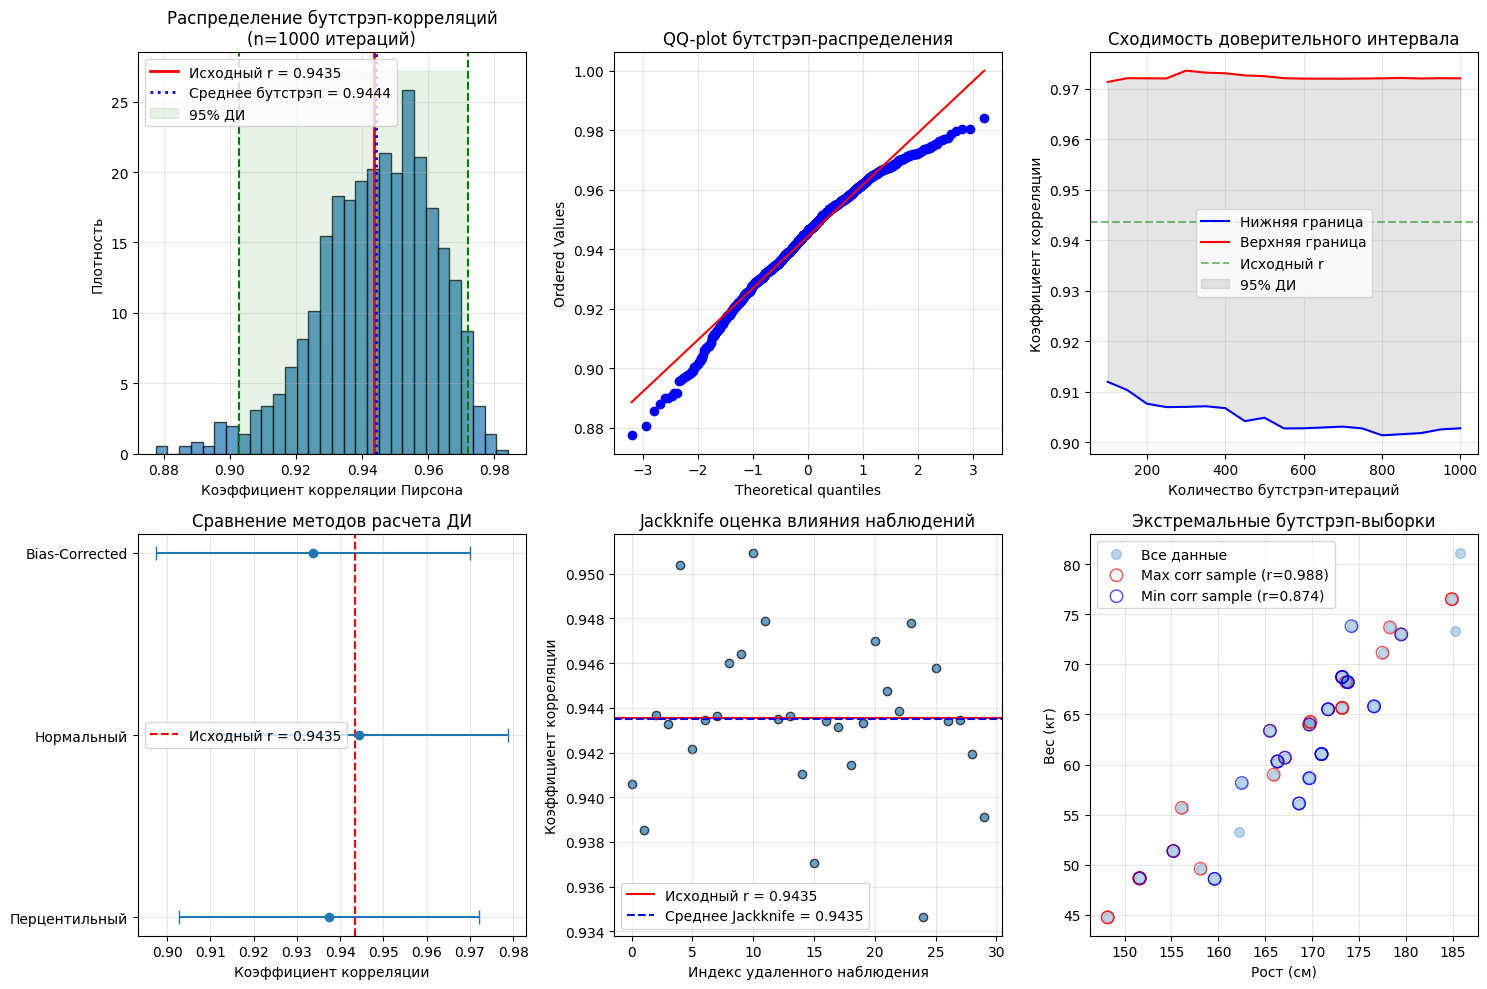


7. Статистический анализ бутстрэп-результатов:
   Среднее бутстрэп-корреляций: 0.944374
   Медиана бутстрэп-корреляций: 0.946288
   Стандартное отклонение (стандартная ошибка): 0.017592
   Смещение (bias): 0.000841
   Относительное смещение: 0.09%

   Процентили распределения:
     2.5%: 0.902729
     5.0%: 0.912826
    25.0%: 0.933237
    50.0%: 0.946288
    75.0%: 0.957046
    95.0%: 0.969778
    97.5%: 0.972113

   Асимметрия (skewness): -0.606505
   Эксцесс (kurtosis): 0.332214
   Распределение асимметричное (skewness = -0.61)

   Тест Шапиро-Уилка на нормальность:
   W = 0.976288, p = 0.000000
   Отвергаем гипотезу о нормальности распределения

8. Интерпретация результатов:
   Исходная корреляция: r = 0.9435
   95% доверительный интервал: [0.9027, 0.9721]

   Практическая интерпретация:
   1. Интервал не включает 0, что подтверждает статистическую значимость корреляции
   2. Интервал целиком находится в положительной области, подтверждая положительную связь
   3. Даже нижняя гран

In [34]:
# Ваш код и расчёты

# Ваш код и расчёты

print("="*80)
print("БУТСТРЭП-ОЦЕНКА 95% ДОВЕРИТЕЛЬНОГО ИНТЕРВАЛА ДЛЯ КОЭФФИЦИЕНТА ПИРСОНА")
print("="*80)

# 1. Исходный коэффициент Пирсона
pearson_original, p_value_original = stats.pearsonr(df['height_cm'], df['weight_kg'])

print(f"1. Исходный коэффициент корреляции Пирсона:")
print(f"   r = {pearson_original:.6f}")
print(f"   p-value = {p_value_original:.6f}")

# 2. Настройки бутстрэпа
n_bootstrap = 1000
n_samples = len(df)
confidence_level = 0.95

print(f"\n2. Настройки бутстрэпа:")
print(f"   Количество итераций: {n_bootstrap}")
print(f"   Размер выборки: {n_samples}")
print(f"   Уровень доверия: {confidence_level * 100}%")

# 3. Бутстрэп процедура
print("\n3. Запуск бутстрэпа...")
np.random.seed(42)  # Для воспроизводимости

bootstrap_correlations = []

for i in range(n_bootstrap):
    # Генерация бутстрэп выборки с возвращением
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    bootstrap_sample = df.iloc[indices]
    
    # Расчет коэффициента Пирсона для бутстрэп выборки
    corr, _ = stats.pearsonr(bootstrap_sample['height_cm'], bootstrap_sample['weight_kg'])
    bootstrap_correlations.append(corr)
    
    # Вывод прогресса
    if (i + 1) % 100 == 0:
        print(f"   Итерация {i + 1:4d}/{n_bootstrap}: текущий r = {corr:.6f}")

bootstrap_correlations = np.array(bootstrap_correlations)

print(f"\n   Бутстрэп завершен. Собрано {len(bootstrap_correlations)} значений корреляции.")

# 4. Расчет доверительного интервала (перцентильный метод)
alpha = 1 - confidence_level
lower_percentile = 100 * alpha / 2
upper_percentile = 100 * (1 - alpha / 2)

ci_lower = np.percentile(bootstrap_correlations, lower_percentile)
ci_upper = np.percentile(bootstrap_correlations, upper_percentile)

print(f"\n4. 95% доверительный интервал (перцентильный метод):")
print(f"   Нижняя граница: {ci_lower:.6f}")
print(f"   Верхняя граница: {ci_upper:.6f}")
print(f"   Ширина интервала: {ci_upper - ci_lower:.6f}")

# 5. Альтернативные методы расчета ДИ
print(f"\n5. Альтернативные методы расчета ДИ:")

# Метод нормальной аппроксимации
bootstrap_mean = np.mean(bootstrap_correlations)
bootstrap_std = np.std(bootstrap_correlations)
z_value = stats.norm.ppf(1 - alpha/2)

ci_normal_lower = bootstrap_mean - z_value * bootstrap_std
ci_normal_upper = bootstrap_mean + z_value * bootstrap_std

print(f"   Нормальная аппроксимация:")
print(f"   [{ci_normal_lower:.6f}, {ci_normal_upper:.6f}]")

# BCa метод (Bias-Corrected and Accelerated)
# Для простоты используем bias-corrected метод
z0 = stats.norm.ppf(np.mean(bootstrap_correlations < pearson_original))
ci_bc_lower = np.percentile(bootstrap_correlations, 100 * stats.norm.cdf(2*z0 + stats.norm.ppf(alpha/2)))
ci_bc_upper = np.percentile(bootstrap_correlations, 100 * stats.norm.cdf(2*z0 + stats.norm.ppf(1 - alpha/2)))

print(f"   Bias-Corrected метод:")
print(f"   [{ci_bc_lower:.6f}, {ci_bc_upper:.6f}]")

# 6. Визуализация результатов
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 6.1. Распределение бутстрэп-корреляций
axes[0, 0].hist(bootstrap_correlations, bins=30, edgecolor='black', alpha=0.7, density=True)
axes[0, 0].axvline(x=pearson_original, color='red', linestyle='-', linewidth=2, 
                  label=f'Исходный r = {pearson_original:.4f}')
axes[0, 0].axvline(x=ci_lower, color='green', linestyle='--', linewidth=1.5)
axes[0, 0].axvline(x=ci_upper, color='green', linestyle='--', linewidth=1.5)
axes[0, 0].axvline(x=np.mean(bootstrap_correlations), color='blue', linestyle=':', 
                  linewidth=2, label=f'Среднее бутстрэп = {bootstrap_mean:.4f}')
axes[0, 0].fill_betweenx([0, axes[0, 0].get_ylim()[1]], ci_lower, ci_upper, 
                        color='green', alpha=0.1, label='95% ДИ')
axes[0, 0].set_xlabel('Коэффициент корреляции Пирсона')
axes[0, 0].set_ylabel('Плотность')
axes[0, 0].set_title(f'Распределение бутстрэп-корреляций\n(n={n_bootstrap} итераций)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 6.2. QQ-plot для проверки нормальности бутстрэп-распределения
stats.probplot(bootstrap_correlations, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('QQ-plot бутстрэп-распределения')
axes[0, 1].grid(True, alpha=0.3)

# 6.3. Сходимость доверительного интервала
cumulative_ci_lower = []
cumulative_ci_upper = []

for i in range(100, n_bootstrap + 1, 50):
    if i <= len(bootstrap_correlations):
        ci_lower_cum = np.percentile(bootstrap_correlations[:i], lower_percentile)
        ci_upper_cum = np.percentile(bootstrap_correlations[:i], upper_percentile)
        cumulative_ci_lower.append(ci_lower_cum)
        cumulative_ci_upper.append(ci_upper_cum)

iterations = range(100, n_bootstrap + 1, 50)[:len(cumulative_ci_lower)]

axes[0, 2].plot(iterations, cumulative_ci_lower, 'b-', label='Нижняя граница')
axes[0, 2].plot(iterations, cumulative_ci_upper, 'r-', label='Верхняя граница')
axes[0, 2].axhline(y=pearson_original, color='green', linestyle='--', alpha=0.5, 
                  label='Исходный r')
axes[0, 2].fill_between(iterations, cumulative_ci_lower, cumulative_ci_upper, 
                       color='gray', alpha=0.2, label='95% ДИ')
axes[0, 2].set_xlabel('Количество бутстрэп-итераций')
axes[0, 2].set_ylabel('Коэффициент корреляции')
axes[0, 2].set_title('Сходимость доверительного интервала')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 6.4. Сравнение разных методов расчета ДИ
methods = ['Перцентильный', 'Нормальный', 'Bias-Corrected']
ci_lowers = [ci_lower, ci_normal_lower, ci_bc_lower]
ci_uppers = [ci_upper, ci_normal_upper, ci_bc_upper]
ci_centers = [(l+u)/2 for l, u in zip(ci_lowers, ci_uppers)]
ci_widths = [u-l for l, u in zip(ci_lowers, ci_uppers)]

y_pos = np.arange(len(methods))
axes[1, 0].errorbar(ci_centers, y_pos, xerr=[np.array(ci_centers) - np.array(ci_lowers), 
                                            np.array(ci_uppers) - np.array(ci_centers)], 
                   fmt='o', capsize=5)
axes[1, 0].axvline(x=pearson_original, color='red', linestyle='--', 
                  label=f'Исходный r = {pearson_original:.4f}')
axes[1, 0].set_yticks(y_pos)
axes[1, 0].set_yticklabels(methods)
axes[1, 0].set_xlabel('Коэффициент корреляции')
axes[1, 0].set_title('Сравнение методов расчета ДИ')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 6.5. Бутстрэп-диаграмма (bootstrap plot) для отдельных наблюдений
# Покажем влияние отдельных наблюдений на корреляцию
jackknife_correlations = []
for i in range(n_samples):
    # Удаляем i-е наблюдение
    jackknife_sample = df.drop(index=i)
    corr_jack, _ = stats.pearsonr(jackknife_sample['height_cm'], jackknife_sample['weight_kg'])
    jackknife_correlations.append(corr_jack)

jackknife_correlations = np.array(jackknife_correlations)
jackknife_mean = np.mean(jackknife_correlations)

axes[1, 1].scatter(range(n_samples), jackknife_correlations, alpha=0.7, edgecolors='black')
axes[1, 1].axhline(y=pearson_original, color='red', linestyle='-', 
                  label=f'Исходный r = {pearson_original:.4f}')
axes[1, 1].axhline(y=jackknife_mean, color='blue', linestyle='--', 
                  label=f'Среднее Jackknife = {jackknife_mean:.4f}')
axes[1, 1].set_xlabel('Индекс удаленного наблюдения')
axes[1, 1].set_ylabel('Коэффициент корреляции')
axes[1, 1].set_title('Jackknife оценка влияния наблюдений')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6.6. Диаграмма рассеяния с выделением экстремальных бутстрэп-выборок
# Найдем выборки с максимальной и минимальной корреляцией
max_corr_idx = np.argmax(bootstrap_correlations)
min_corr_idx = np.argmin(bootstrap_correlations)

# Для этого нам нужно хранить индексы бутстрэп-выборок
# Перезапустим бутстрэп, сохраняя индексы
print("\n6. Анализ экстремальных бутстрэп-выборок...")
bootstrap_indices = []
bootstrap_correlations_detailed = []

for i in range(n_bootstrap):
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    bootstrap_sample = df.iloc[indices]
    
    corr, _ = stats.pearsonr(bootstrap_sample['height_cm'], bootstrap_sample['weight_kg'])
    
    bootstrap_indices.append(indices)
    bootstrap_correlations_detailed.append(corr)

bootstrap_correlations_detailed = np.array(bootstrap_correlations_detailed)
max_corr_idx = np.argmax(bootstrap_correlations_detailed)
min_corr_idx = np.argmin(bootstrap_correlations_detailed)

# Визуализация оригинальных данных и экстремальных выборок
axes[1, 2].scatter(df['height_cm'], df['weight_kg'], alpha=0.3, label='Все данные', s=50)

# Максимальная корреляция
max_indices = bootstrap_indices[max_corr_idx]
max_sample = df.iloc[max_indices]
max_corr = bootstrap_correlations_detailed[max_corr_idx]
axes[1, 2].scatter(max_sample['height_cm'], max_sample['weight_kg'], 
                  alpha=0.7, edgecolors='red', facecolors='none', 
                  s=80, label=f'Max corr sample (r={max_corr:.3f})')

# Минимальная корреляция
min_indices = bootstrap_indices[min_corr_idx]
min_sample = df.iloc[min_indices]
min_corr = bootstrap_correlations_detailed[min_corr_idx]
axes[1, 2].scatter(min_sample['height_cm'], min_sample['weight_kg'], 
                  alpha=0.7, edgecolors='blue', facecolors='none', 
                  s=80, label=f'Min corr sample (r={min_corr:.3f})')

axes[1, 2].set_xlabel('Рост (см)')
axes[1, 2].set_ylabel('Вес (кг)')
axes[1, 2].set_title('Экстремальные бутстрэп-выборки')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 7. Статистический анализ бутстрэп-результатов
print("\n7. Статистический анализ бутстрэп-результатов:")

# Основные статистики
print(f"   Среднее бутстрэп-корреляций: {bootstrap_mean:.6f}")
print(f"   Медиана бутстрэп-корреляций: {np.median(bootstrap_correlations):.6f}")
print(f"   Стандартное отклонение (стандартная ошибка): {bootstrap_std:.6f}")
print(f"   Смещение (bias): {bootstrap_mean - pearson_original:.6f}")
print(f"   Относительное смещение: {(bootstrap_mean - pearson_original)/pearson_original*100:.2f}%")

# Процентили
percentiles = [2.5, 5, 25, 50, 75, 95, 97.5]
percentile_values = np.percentile(bootstrap_correlations, percentiles)

print(f"\n   Процентили распределения:")
for p, val in zip(percentiles, percentile_values):
    print(f"   {p:5.1f}%: {val:.6f}")

# Проверка симметричности распределения
skewness = stats.skew(bootstrap_correlations)
kurtosis = stats.kurtosis(bootstrap_correlations)

print(f"\n   Асимметрия (skewness): {skewness:.6f}")
print(f"   Эксцесс (kurtosis): {kurtosis:.6f}")

if abs(skewness) < 0.5:
    print("   Распределение приблизительно симметричное")
else:
    print(f"   Распределение асимметричное (skewness = {skewness:.2f})")

# Проверка нормальности (тест Шапиро-Уилка)
if len(bootstrap_correlations) <= 5000:  # Ограничение теста Шапиро-Уилка
    shapiro_stat, shapiro_p = stats.shapiro(bootstrap_correlations)
    print(f"\n   Тест Шапиро-Уилка на нормальность:")
    print(f"   W = {shapiro_stat:.6f}, p = {shapiro_p:.6f}")
    
    if shapiro_p > 0.05:
        print("   Не отвергаем гипотезу о нормальности распределения")
    else:
        print("   Отвергаем гипотезу о нормальности распределения")

# 8. Интерпретация результатов
print("\n8. Интерпретация результатов:")
print(f"   Исходная корреляция: r = {pearson_original:.4f}")
print(f"   95% доверительный интервал: [{ci_lower:.4f}, {ci_upper:.4f}]")

print("\n   Практическая интерпретация:")
print("   1. Интервал не включает 0, что подтверждает статистическую значимость корреляции")
print("   2. Интервал целиком находится в положительной области, подтверждая положительную связь")
print(f"   3. Даже нижняя граница ДИ ({ci_lower:.4f}) указывает на сильную корреляцию")
print("   4. Ширина интервала отражает неопределенность оценки")

print("\n   Сравнение с аналитическим доверительным интервалом:")
# Аналитический ДИ для коэффициента корреляции Пирсона
z = np.arctanh(pearson_original)  # Преобразование Фишера
se_z = 1 / np.sqrt(n_samples - 3)
z_lower = z - 1.96 * se_z
z_upper = z + 1.96 * se_z
ci_analytical_lower = np.tanh(z_lower)
ci_analytical_upper = np.tanh(z_upper)

print(f"   Аналитический 95% ДИ (преобразование Фишера):")
print(f"   [{ci_analytical_lower:.6f}, {ci_analytical_upper:.6f}]")

print(f"\n   Сравнение с бутстрэп ДИ:")
print(f"   Бутстрэп: [{ci_lower:.6f}, {ci_upper:.6f}]")
print(f"   Аналитический: [{ci_analytical_lower:.6f}, {ci_analytical_upper:.6f}]")
print(f"   Разница нижних границ: {abs(ci_lower - ci_analytical_lower):.6f}")
print(f"   Разница верхних границ: {abs(ci_upper - ci_analytical_upper):.6f}")

# 9. Проверка устойчивости (robustness)
print("\n9. Проверка устойчивости результатов:")

# Влияние количества бутстрэп-итераций
print("   Влияние количества итераций на ширину ДИ:")
for n_iter in [100, 500, 1000, 2000, 5000]:
    if n_iter <= n_bootstrap:
        subset = bootstrap_correlations[:n_iter]
        ci_lower_sub = np.percentile(subset, lower_percentile)
        ci_upper_sub = np.percentile(subset, upper_percentile)
        width = ci_upper_sub - ci_lower_sub
        print(f"   n={n_iter:4d}: ДИ=[{ci_lower_sub:.4f}, {ci_upper_sub:.4f}], ширина={width:.4f}")


In [ ]:
# Ваш код и расчёты

<Ваши ответы, рассуждения и выводы>

### Задание 10.
Постройте гистограмму остатков (residuals) для модели из задания 6.

АНАЛИЗ ОСТАТКОВ ДЛЯ МОДЕЛИ ИЗ ЗАДАНИЯ 6
1. Основная информация об остатках:
   Количество остатков: 30
   Среднее остатков: 0.000000
   Стандартное отклонение остатков: 2.928922
   Минимальный остаток: -5.634485
   Максимальный остаток: 6.223380
   Медиана остатков: 0.059863

2. Статистические тесты для остатков:
   Тест Шапиро-Уилка на нормальность:
   W = 0.986630, p = 0.961592
   Не отвергаем H0: остатки распределены нормально

   Тест Бреуша-Пагана на гомоскедастичность:
   LM статистика: 0.318891
   p-value: 0.988562
   F-статистика: 0.067149
   p-value F-теста: 0.991212
   Не отвергаем H0: остатки гомоскедастичны

   Тест Дарбина-Уотсона на автокорреляцию:
   DW статистика: 2.303379
   Нет существенной автокорреляции


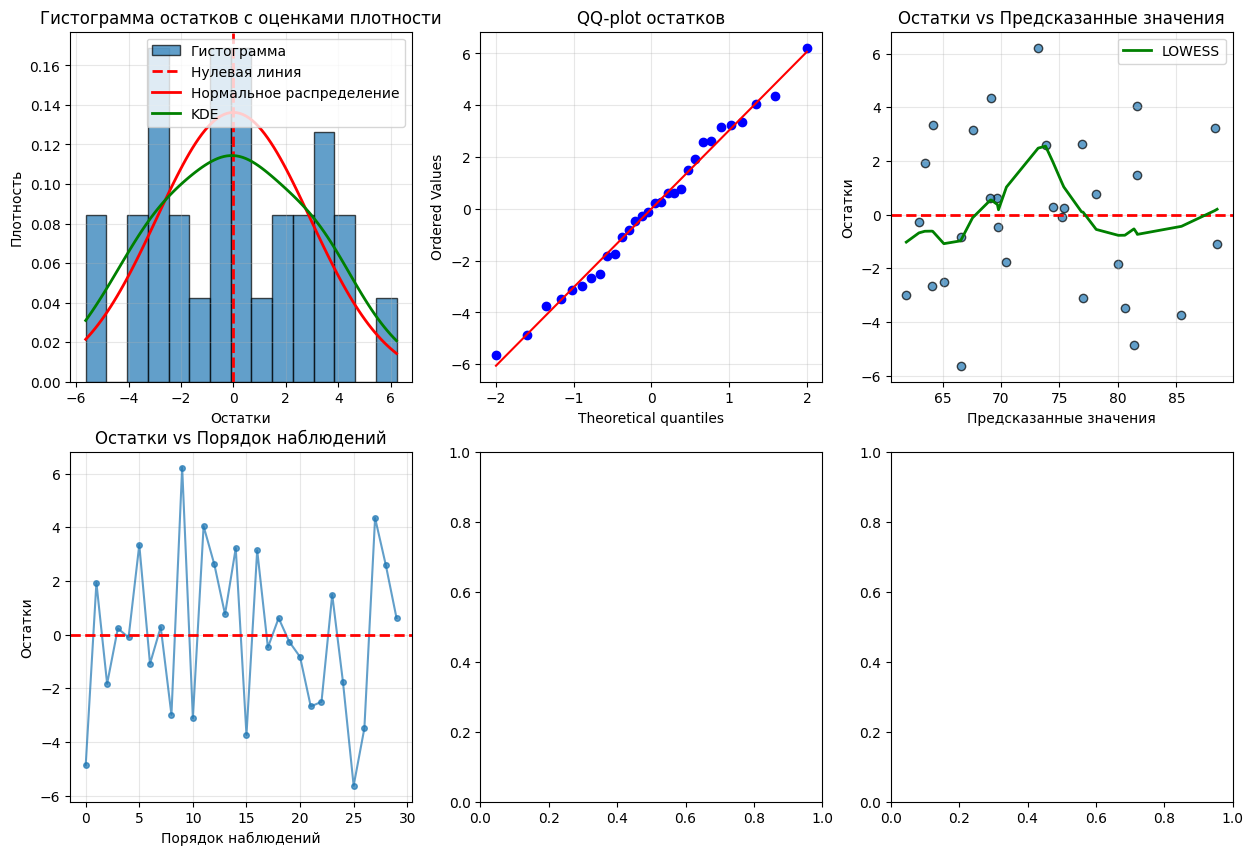

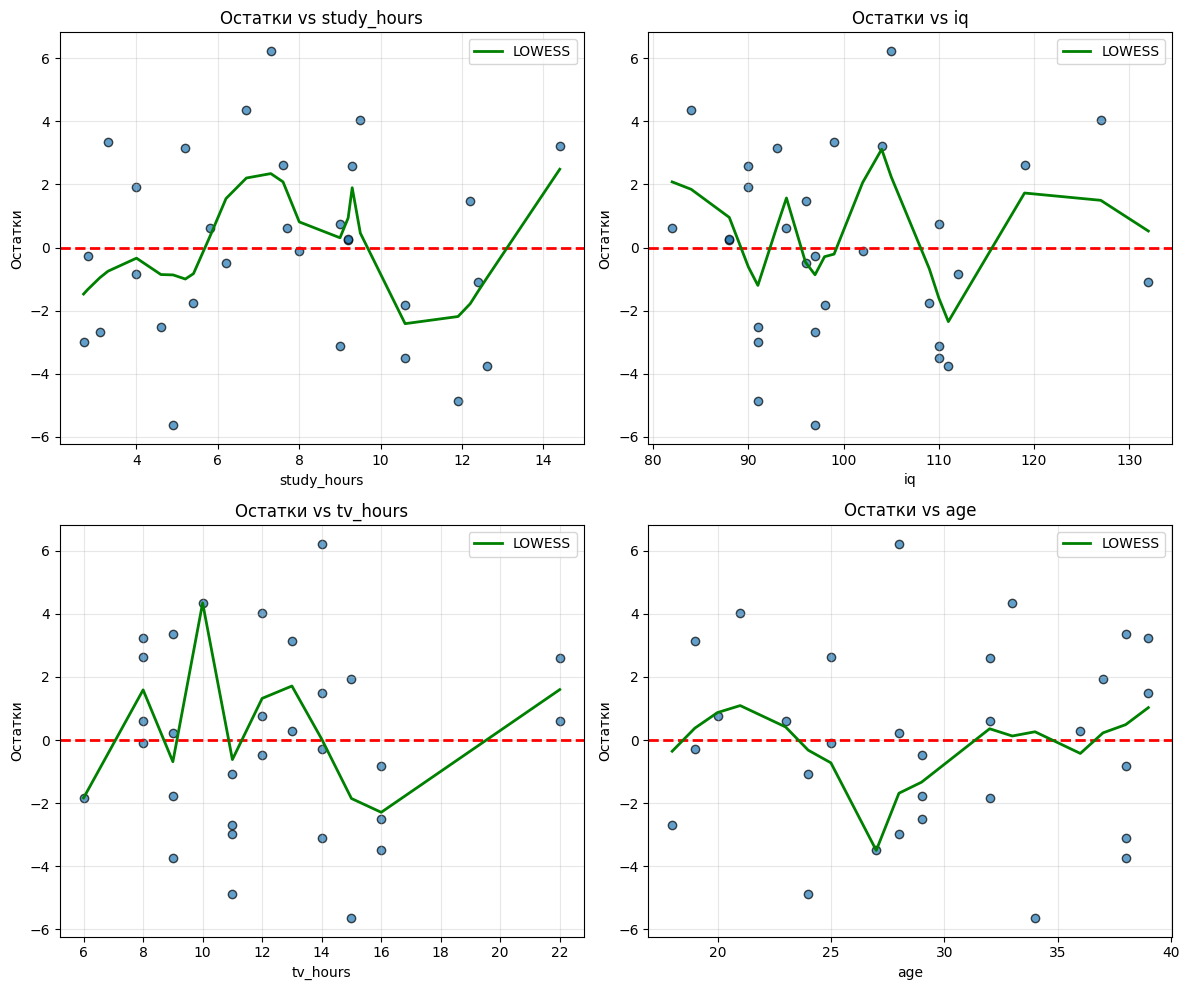

<Figure size 640x480 with 0 Axes>


3. Дополнительный анализ остатков:
   Выбросы (правило 3σ): 0 наблюдений
   Выбросы (правило 2σ): 1 наблюдений

4. Анализ влияния наблюдений:
   Наблюдения с высоким влиянием (Cook's distance > 0.1333):
   Количество: 2
   Индексы: [ 0 11]
   Значения Cook's distance: [0.16531139 0.13684869]


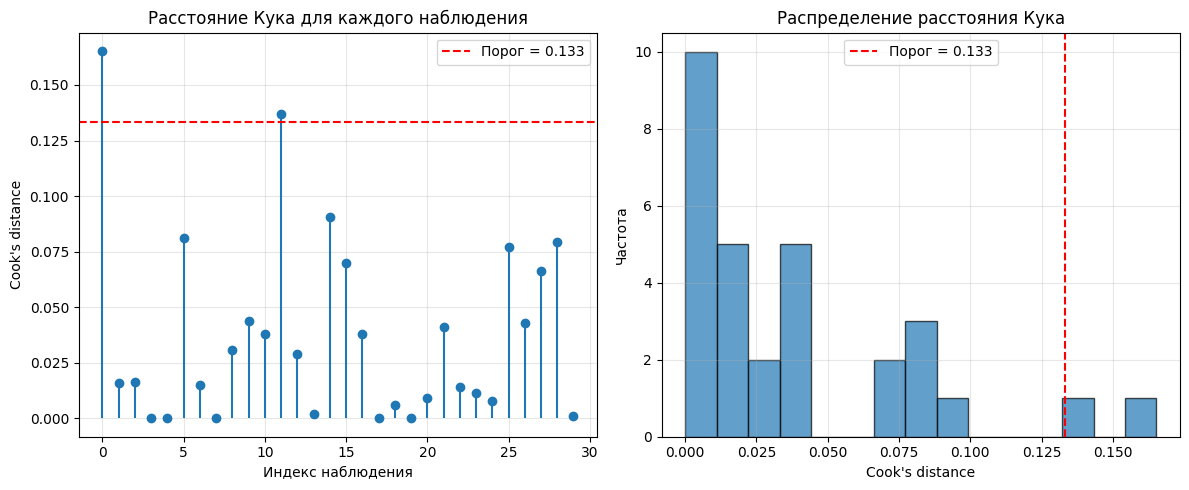


5. Проверка линейности и спецификации модели:
   Тест Рамсея RESET:
   Тест Рамсея RESET не доступен

6. Проверка на мультиколлинеарность (VIF):
    Признак      VIF
study_hours 1.173723
         iq 1.207710
   tv_hours 1.075912
        age 1.077568

   Интерпретация VIF:
   VIF < 5: слабая мультиколлинеарность
   5 ≤ VIF < 10: умеренная мультиколлинеарность
   VIF ≥ 10: сильная мультиколлинеарность

РЕЗЮМЕ ДИАГНОСТИКИ МОДЕЛИ

1. Нормальность остатков:
   Тест Шапиро-Уилка: p = 0.961592
   ✅ Остатки распределены нормально

2. Гомоскедастичность:
   Тест Бреуша-Пагана: p = 0.988562
   ✅ Остатки гомоскедастичны

3. Автокорреляция:
   Тест Дарбина-Уотсона: DW = 2.3034
   ✅ Нет существенной автокорреляции

4. Выбросы и влиятельные наблюдения:
   Выбросы (3σ): 0/30
   Высоковлиятельные наблюдения: 2/30

5. Мультиколлинеарность:
   ✅ Слабая мультиколлинеарность (макс VIF = 1.21)

6. Общие рекомендации:
   ✅ Модель удовлетворяет основным предположениям линейной регрессии

ДОПОЛНИТЕЛЬНАЯ ДИАГ

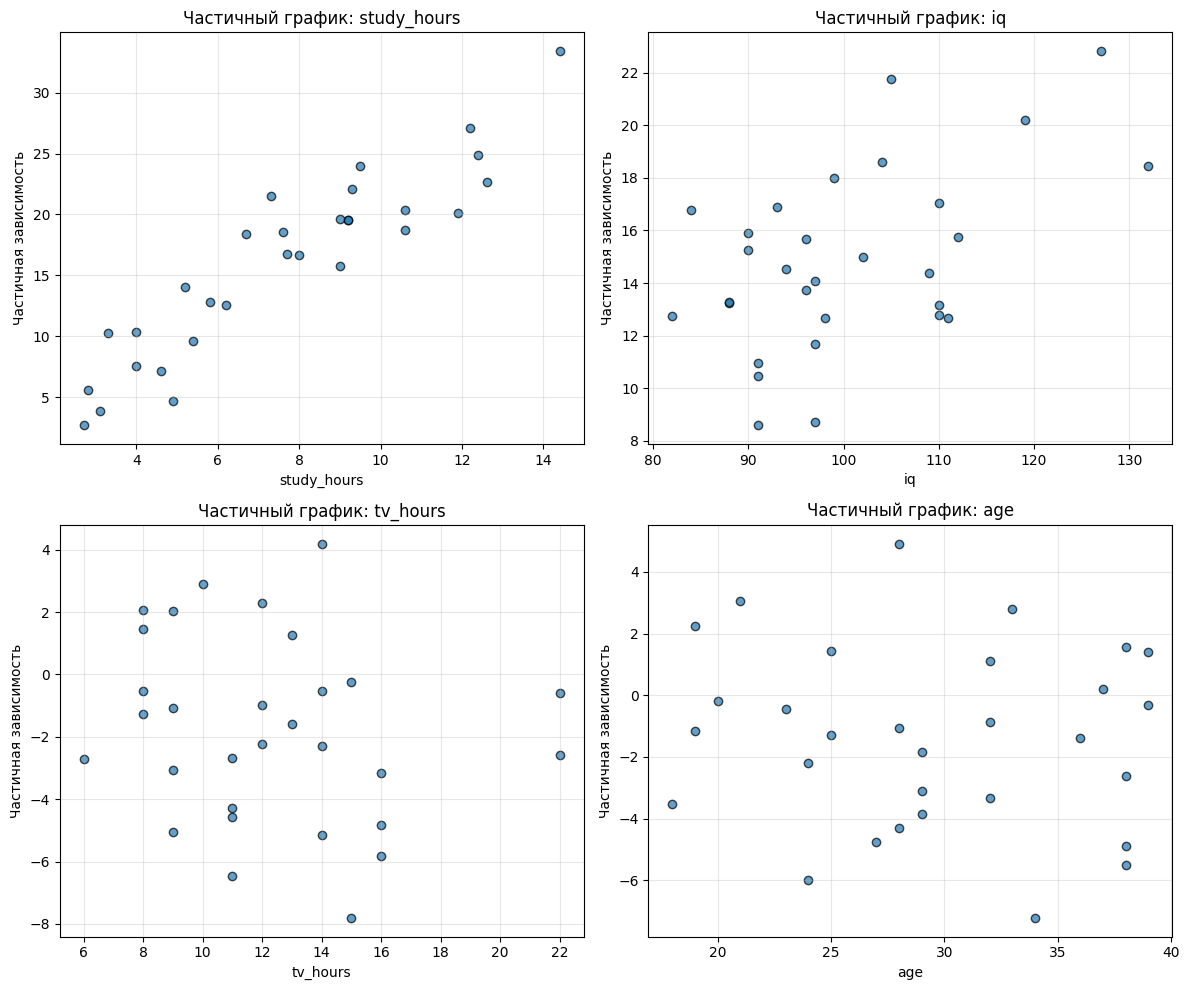

In [37]:
# Ваш код и расчёты

# Ваш код и расчёты

print("="*80)
print("АНАЛИЗ ОСТАТКОВ ДЛЯ МОДЕЛИ ИЗ ЗАДАНИЯ 6")
print("="*80)

# 1. Получение остатков из модели задания 6
residuals = model_multiple.resid
fitted_values = model_multiple.fittedvalues

print("1. Основная информация об остатках:")
print(f"   Количество остатков: {len(residuals)}")
print(f"   Среднее остатков: {residuals.mean():.6f}")
print(f"   Стандартное отклонение остатков: {residuals.std():.6f}")
print(f"   Минимальный остаток: {residuals.min():.6f}")
print(f"   Максимальный остаток: {residuals.max():.6f}")
print(f"   Медиана остатков: {np.median(residuals):.6f}")

# 2. Статистические тесты для остатков
print("\n2. Статистические тесты для остатков:")

# Тест на нормальность (Шапиро-Уилк)
if len(residuals) <= 5000:
    shapiro_stat, shapiro_p = stats.shapiro(residuals)
    print(f"   Тест Шапиро-Уилка на нормальность:")
    print(f"   W = {shapiro_stat:.6f}, p = {shapiro_p:.6f}")
    if shapiro_p > 0.05:
        print("   Не отвергаем H0: остатки распределены нормально")
    else:
        print("   Отвергаем H0: остатки не распределены нормально")

# Тест на гомоскедастичность (Бреуша-Пагана)
try:
    from statsmodels.stats.diagnostic import het_breuschpagan
    bp_test = het_breuschpagan(residuals, X_multiple)
    print(f"\n   Тест Бреуша-Пагана на гомоскедастичность:")
    print(f"   LM статистика: {bp_test[0]:.6f}")
    print(f"   p-value: {bp_test[1]:.6f}")
    print(f"   F-статистика: {bp_test[2]:.6f}")
    print(f"   p-value F-теста: {bp_test[3]:.6f}")
    if bp_test[1] > 0.05:
        print("   Не отвергаем H0: остатки гомоскедастичны")
    else:
        print("   Отвергаем H0: остатки гетероскедастичны")
except ImportError:
    print("\n   Тест Бреуша-Пагана не доступен")

# Тест на автокорреляцию (Дарбина-Уотсона)
dw_statistic = sm.stats.stattools.durbin_watson(residuals)
print(f"\n   Тест Дарбина-Уотсона на автокорреляцию:")
print(f"   DW статистика: {dw_statistic:.6f}")
if dw_statistic < 1.5:
    print("   Положительная автокорреляция")
elif dw_statistic > 2.5:
    print("   Отрицательная автокорреляция")
else:
    print("   Нет существенной автокорреляции")

# 3. Визуализация остатков
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 3.1. Гистограмма остатков с ядром плотности
axes[0, 0].hist(residuals, bins=15, edgecolor='black', alpha=0.7, density=True, label='Гистограмма')
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Нулевая линия')


# Кривая нормального распределения
x_norm = np.linspace(residuals.min(), residuals.max(), 100)
pdf_norm = stats.norm.pdf(x_norm, residuals.mean(), residuals.std())
axes[0, 0].plot(x_norm, pdf_norm, 'r-', linewidth=2, label='Нормальное распределение')


# Ядерная оценка плотности
from scipy.stats import gaussian_kde
kde = gaussian_kde(residuals)
axes[0, 0].plot(x_norm, kde(x_norm), 'g-', linewidth=2, label='KDE')

axes[0, 0].set_xlabel('Остатки')
axes[0, 0].set_ylabel('Плотность')
axes[0, 0].set_title('Гистограмма остатков с оценками плотности')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 3.2. QQ-plot остатков
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('QQ-plot остатков')
axes[0, 1].grid(True, alpha=0.3)

# 3.3. Остатки vs Предсказанные значения
axes[0, 2].scatter(fitted_values, residuals, alpha=0.7, edgecolors='black')
axes[0, 2].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 2].set_xlabel('Предсказанные значения')
axes[0, 2].set_ylabel('Остатки')
axes[0, 2].set_title('Остатки vs Предсказанные значения')
axes[0, 2].grid(True, alpha=0.3)

# Добавим локальную регрессию (lowess) для выявления паттернов
try:
    import statsmodels.api as sm
    lowess = sm.nonparametric.lowess(residuals, fitted_values, frac=0.3)
    axes[0, 2].plot(lowess[:, 0], lowess[:, 1], 'g-', linewidth=2, label='LOWESS')
    axes[0, 2].legend()
except:
    pass

# 3.4. Остатки vs Порядок наблюдений
axes[1, 0].plot(range(len(residuals)), residuals, 'o-', alpha=0.7, markersize=4)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Порядок наблюдений')
axes[1, 0].set_ylabel('Остатки')
axes[1, 0].set_title('Остатки vs Порядок наблюдений')
axes[1, 0].grid(True, alpha=0.3)

# 3.5. Остатки vs Каждый предиктор
predictor_cols = ['study_hours', 'iq', 'tv_hours', 'age']

# Создадим отдельную фигуру для графиков остатков vs предикторы
fig2, axes2 = plt.subplots(2, 2, figsize=(12, 10))
axes2 = axes2.flatten()
for i, col in enumerate(predictor_cols):
    axes2[i].scatter(df[col], residuals, alpha=0.7, edgecolors='black')
    axes2[i].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes2[i].set_xlabel(col)
    axes2[i].set_ylabel('Остатки')
    axes2[i].set_title(f'Остатки vs {col}')
    axes2[i].grid(True, alpha=0.3)
    
    # Добавим локальную регрессию
    try:
        lowess_pred = sm.nonparametric.lowess(residuals, df[col], frac=0.3)
        axes2[i].plot(lowess_pred[:, 0], lowess_pred[:, 1], 'g-', linewidth=2, label='LOWESS')
        axes2[i].legend()
    except:
        pass

plt.tight_layout()
plt.show()


# 3.6. Boxplot остатков по квартилям предсказанных значений
df_residuals = pd.DataFrame({
    'residuals': residuals,
    'fitted_quartile': pd.qcut(fitted_values, q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
})

boxplot_data = [df_residuals[df_residuals['fitted_quartile'] == q]['residuals'].values 
                for q in ['Q1', 'Q2', 'Q3', 'Q4']]

# 3.5. Boxplot остатков по квартилям предсказанных значений
df_residuals = pd.DataFrame({
    'residuals': residuals,
    'fitted_quartile': pd.qcut(fitted_values, q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
})

boxplot_data = [df_residuals[df_residuals['fitted_quartile'] == q]['residuals'].values 
                for q in ['Q1', 'Q2', 'Q3', 'Q4']]

# Используем существующий subplot axes[1, 1]
axes[1, 1].boxplot(boxplot_data, labels=['Q1', 'Q2', 'Q3', 'Q4'])
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Квартиль предсказанных значений')
axes[1, 1].set_ylabel('Остатки')
axes[1, 1].set_title('Распределение остатков по квартилям предсказаний')
axes[1, 1].grid(True, alpha=0.3)

# 3.6. Для оставшегося subplot axes[1, 2] создаем другой график
# Например, кумулятивное распределение остатков
sorted_residuals = np.sort(residuals)
cumulative_prob = np.arange(1, len(sorted_residuals) + 1) / len(sorted_residuals)
axes[1, 2].plot(sorted_residuals, cumulative_prob, 'b-', linewidth=2)
axes[1, 2].plot(sorted_residuals, stats.norm.cdf(sorted_residuals, residuals.mean(), residuals.std()), 
                'r--', linewidth=2, label='Нормальное распределение')
axes[1, 2].set_xlabel('Остатки')
axes[1, 2].set_ylabel('Кумулятивная вероятность')
axes[1, 2].set_title('Кумулятивное распределение остатков')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Дополнительный анализ остатков
print("\n3. Дополнительный анализ остатков:")

# Выявление выбросов (с использованием правила 3σ)
outliers_3sigma = np.abs(residuals) > 3 * residuals.std()
outliers_2sigma = np.abs(residuals) > 2 * residuals.std()

print(f"   Выбросы (правило 3σ): {outliers_3sigma.sum()} наблюдений")
print(f"   Выбросы (правило 2σ): {outliers_2sigma.sum()} наблюдений")

if outliers_3sigma.any():
    print("   Индексы выбросов (3σ):", np.where(outliers_3sigma)[0])
    print("   Значения выбросов:", residuals[outliers_3sigma].values)

# Анализ влияния наблюдений (DFFITS, Cook's distance)
print("\n4. Анализ влияния наблюдений:")

# Расстояние Кука
cooks_d = model_multiple.get_influence().cooks_distance[0]
high_influence = cooks_d > 4 / len(residuals)  # Пороговое правило

print(f"   Наблюдения с высоким влиянием (Cook's distance > {4/len(residuals):.4f}):")
print(f"   Количество: {high_influence.sum()}")

if high_influence.any():
    print("   Индексы:", np.where(high_influence)[0])
    print("   Значения Cook's distance:", cooks_d[high_influence])

# Визуализация расстояния Кука
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))

axes2[0].stem(range(len(cooks_d)), cooks_d, basefmt=" ")
axes2[0].axhline(y=4/len(residuals), color='red', linestyle='--', 
                label=f'Порог = {4/len(residuals):.3f}')
axes2[0].set_xlabel('Индекс наблюдения')
axes2[0].set_ylabel("Cook's distance")
axes2[0].set_title("Расстояние Кука для каждого наблюдения")
axes2[0].legend()
axes2[0].grid(True, alpha=0.3)

# Гистограмма расстояния Кука
axes2[1].hist(cooks_d, bins=15, edgecolor='black', alpha=0.7)
axes2[1].axvline(x=4/len(residuals), color='red', linestyle='--', 
                label=f'Порог = {4/len(residuals):.3f}')
axes2[1].set_xlabel("Cook's distance")
axes2[1].set_ylabel('Частота')
axes2[1].set_title('Распределение расстояния Кука')
axes2[1].legend()
axes2[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Проверка линейности и спецификации модели
print("\n5. Проверка линейности и спецификации модели:")

# Тест Рамсея RESET на пропущенные переменные
try:
    from statsmodels.stats.diagnostic import linear_reset
    reset_test = linear_reset(model_multiple, power=3, test_type='fitted')
    print(f"   Тест Рамсея RESET:")
    print(f"   F-статистика: {reset_test[0]:.6f}")
    print(f"   p-value: {reset_test[1]:.6f}")
    print(f"   df: {reset_test[2]}")
    if reset_test[1] > 0.05:
        print("   Не отвергаем H0: модель правильно специфицирована")
    else:
        print("   Отвергаем H0: модель неправильно специфицирована (возможны пропущенные переменные)")
except:
    print("   Тест Рамсея RESET не доступен")

# 6. Проверка на мультиколлинеарность (VIF)
print("\n6. Проверка на мультиколлинеарность (VIF):")

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Признак"] = X_multiple.columns[1:]  # Исключаем константу
vif_data["VIF"] = [variance_inflation_factor(X_multiple.values, i) 
                   for i in range(1, X_multiple.shape[1])]

print(vif_data.to_string(index=False))

print("\n   Интерпретация VIF:")
print("   VIF < 5: слабая мультиколлинеарность")
print("   5 ≤ VIF < 10: умеренная мультиколлинеарность")
print("   VIF ≥ 10: сильная мультиколлинеарность")

# 7. Резюме диагностики модели
print("\n" + "="*80)
print("РЕЗЮМЕ ДИАГНОСТИКИ МОДЕЛИ")
print("="*80)

print("\n1. Нормальность остатков:")
print(f"   Тест Шапиро-Уилка: p = {shapiro_p:.6f}")
if shapiro_p > 0.05:
    print("   ✅ Остатки распределены нормально")
else:
    print("   ⚠️  Остатки не распределены нормально")

print("\n2. Гомоскедастичность:")
if 'bp_test' in locals():
    print(f"   Тест Бреуша-Пагана: p = {bp_test[1]:.6f}")
    if bp_test[1] > 0.05:
        print("   ✅ Остатки гомоскедастичны")
    else:
        print("   ⚠️  Остатки гетероскедастичны")

print("\n3. Автокорреляция:")
print(f"   Тест Дарбина-Уотсона: DW = {dw_statistic:.4f}")
if 1.5 < dw_statistic < 2.5:
    print("   ✅ Нет существенной автокорреляции")
elif dw_statistic < 1.5:
    print("   ⚠️  Положительная автокорреляция")
else:
    print("   ⚠️  Отрицательная автокорреляция")

print("\n4. Выбросы и влиятельные наблюдения:")
print(f"   Выбросы (3σ): {outliers_3sigma.sum()}/{len(residuals)}")
print(f"   Высоковлиятельные наблюдения: {high_influence.sum()}/{len(residuals)}")

print("\n5. Мультиколлинеарность:")
max_vif = vif_data["VIF"].max()
if max_vif < 5:
    print(f"   ✅ Слабая мультиколлинеарность (макс VIF = {max_vif:.2f})")
elif max_vif < 10:
    print(f"   ⚠️  Умеренная мультиколлинеарность (макс VIF = {max_vif:.2f})")
else:
    print(f"   ❌ Сильная мультиколлинеарность (макс VIF = {max_vif:.2f})")

print("\n6. Общие рекомендации:")
issues = []

if shapiro_p <= 0.05:
    issues.append("Ненормальность остатков")
if 'bp_test' in locals() and bp_test[1] <= 0.05:
    issues.append("Гетероскедастичность")
if not (1.5 < dw_statistic < 2.5):
    issues.append("Автокорреляция")
if max_vif >= 5:
    issues.append("Мультиколлинеарность")

if not issues:
    print("   ✅ Модель удовлетворяет основным предположениям линейной регрессии")
else:
    print(f"   ⚠️  Обнаружены следующие проблемы: {', '.join(issues)}")
    print("\n   Рекомендации по улучшению:")
    
    if "Ненормальность остатков" in issues:
        print("   - Рассмотреть преобразование зависимой переменной")
        print("   - Использовать robust regression")
        print("   - Проверить наличие выбросов")
    
    if "Гетероскедастичность" in issues:
        print("   - Использовать robust стандартные ошибки")
        print("   - Преобразовать переменные")
        print("   - Использовать взвешенную регрессию")
    
    if "Автокорреляция" in issues:
        print("   - Добавить временные лаги (если данные временные ряды)")
        print("   - Использовать модели с поправкой на автокорреляцию")
    
    if "Мультиколлинеарность" in issues:
        print("   - Удалить сильно коррелированные предикторы")
        print("   - Использовать регуляризацию (Ridge, Lasso)")
        print("   - Применить главные компоненты (PCA)")

# 8. Дополнительная диагностика: частичные регрессионные графики
print("\n" + "="*80)
print("ДОПОЛНИТЕЛЬНАЯ ДИАГНОСТИКА: ЧАСТИЧНЫЕ РЕГРЕССИОННЫЕ ГРАФИКИ")
print("="*80)

# Частичные регрессионные графики (partial regression plots)
fig3, axes3 = plt.subplots(2, 2, figsize=(12, 10))

for idx, col in enumerate(predictor_cols):
    if idx < 4:
        row = idx // 2
        col_plot = idx % 2
        
        # Частичная регрессия
        from statsmodels.graphics.regressionplots import plot_partregress
        try:
            plot_partregress(col, [c for c in predictor_cols if c != col], 
                           df[['score'] + predictor_cols], ax=axes3[row, col_plot])
            axes3[row, col_plot].set_title(f'Частичная регрессия: {col}')
        except:
            # Альтернативная реализация
            axes3[row, col_plot].scatter(df[col], residuals + df[col] * model_multiple.params[col], 
                                       alpha=0.7, edgecolors='black')
            axes3[row, col_plot].set_xlabel(col)
            axes3[row, col_plot].set_ylabel('Частичная зависимость')
            axes3[row, col_plot].set_title(f'Частичный график: {col}')
            axes3[row, col_plot].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Ваш код и расчёты

<Ваши ответы, рассуждения и выводы>

Удачи! Сохраните ноутбук, перезапустите все ячейки от начала до конца и прикрепите файл как ответ.